# Estimate the number of signal events

## Objectives

* **Estimate the number of signal events** using the extended maximum likelihood fit and **simulated experiments**.

* **Estimate the p-value of the null hypothesis** (no signal present).

## Physics

We are going to estimate the number of signal events using an extended maximum likelihood fit. 

We will test the method here with **simulated data**.

Similarly to how we computed the number of background events in the blind sample, we fit the energy distribution in the enlarged energy window to the energy template distributions of the signal and background samples. Their PDFs, $g_k(E), \;\; k = \mathrm{Bi}, \mathrm{Tl}, \beta\beta0\nu$, are obtained from simulated data.

We test the fitting method by generating an experiment with a number of background events compatible with our estimates from the blind data, and a trial number of signal events.

We can vary the number of signal events to study the performance of the fit.

Finally, we test the p-value of the null hypothesis for a given simulated experiment.

## Analysis

#### Importing modules

In [187]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [188]:
import numpy  as np
import tables as tb
import pandas as pd
import matplotlib.pyplot as plt

import scipy.constants as constants
import scipy.stats     as stats
import scipy.optimize  as optimize

import warnings
warnings.filterwarnings('ignore')

In [189]:
import os, sys
from pathlib import Path

# Find the project root: honours FANAL_ROOT env-var, otherwise walks up from cwd
_env = os.environ.get('FANAL_ROOT') or os.environ.get('USCFANALDIR')
if _env and Path(_env, 'data').is_dir():
    rootpath = str(Path(_env).resolve())
else:
    rootpath = str(next(p for p in [Path.cwd(), *Path.cwd().parents]
                        if (p / 'data').is_dir() and (p / 'ana').is_dir()))
if rootpath not in sys.path:
    sys.path.insert(0, rootpath)
print('Fanal root : ', rootpath)

Fanal root :  /home/daniel/GitHub/Grupo_beta_DM


In [190]:
import core.pltext  as pltext   # extensions for plotting histograms
import core.hfit    as hfit     # extension to fit histograms
import core.efit    as efit     # Fit Utilites - Includes Extend Likelihood Fit with composite PDFs
import core.utils   as ut       # generic utilities
import ana.fanal    as fn       # analysis functions specific to fanal
import ana.pltfanal as pltfn    # plotting for fanal
import     collpars as collpars # collaboration specific parameters
pltext.style()

### Main parameters

In [191]:
coll          = collpars.collaboration
sel_ntracks   = collpars.sel_ntracks
sel_eblob2    = collpars.sel_eblob2
sel_erange    = collpars.sel_erange
sel_eroi      = collpars.sel_eroi

print('Collaboration             : {:s}'.format(coll))
print('number of tracks range    : {:6d}'.format(sel_ntracks))
print('Blob-2 energy range       : {:6.3f}  MeV'.format(sel_eblob2))
print('Energy range              : ({:6.3f}, {:6.3f}) MeV'.format(*sel_erange))
print('Energy RoI range          : ({:6.3f}, {:6.3f}) MeV'.format(*sel_eroi))

Collaboration             : new_beta
number of tracks range    :      1
Blob-2 energy range       :  0.400  MeV
Energy range              : ( 2.440,  2.470) MeV
Energy RoI range          : ( 2.445,  2.470) MeV


In [192]:
# list of the analysis selection variables names and ranges
ntracks_range = (sel_ntracks, sel_ntracks + 0.1)
eblob2_range  = (sel_eblob2, sel_erange[1]) # MeV


varnames  = ['num_tracks', 'blob2_E', 'E']
varranges = [ntracks_range, eblob2_range, sel_erange]
print('ana varnames  : ', varnames)
print('ana varranges : ', varranges)

# list of the reference selection variable names and ranges to get pdfs for the MC
refnames  = ['num_tracks', 'E']
refranges = [ntracks_range, sel_erange]
print('ref varnames  : ', refnames)
print('ref varranges : ', refranges)


ana varnames  :  ['num_tracks', 'blob2_E', 'E']
ana varranges :  [(1, 1.1), (0.4, 2.47), (2.44, 2.47)]
ref varnames  :  ['num_tracks', 'E']
ref varranges :  [(1, 1.1), (2.44, 2.47)]


In [193]:
# number of  blind events
n_Bi_total = collpars.n_Bi_total
n_Tl_total = collpars.n_Tl_total

eff_Bi_E   = collpars.eff_Bi_E
eff_Tl_E   = collpars.eff_Tl_E
eff_bb_E   = collpars.eff_bb_E
print('Number of bkg events in full data : Bi = {:6.2f}, Tl = {:6.2f}.'.format(n_Bi_total, n_Tl_total))

Number of bkg events in full data : Bi = 1184.86, Tl = 3729.61.


### the data

In [194]:
# set the path to the data directory and filenames
dirpath = rootpath+'/data/'
filename = 'fanal_' + coll + '.h5'
print('Data path and filename : ', dirpath + filename)

# access the simulated data (DataFrames) for the different samples (Bi, Tl, bb) located in the data file
mcbi = pd.read_hdf(dirpath + filename, key = 'mc/bi214').fillna(0.)
mctl = pd.read_hdf(dirpath + filename, key = 'mc/tl208').fillna(0.)
mcbb = pd.read_hdf(dirpath + filename, key = 'mc/bb0nu').fillna(0.)

# set the names of the samples
mc_samples         = [mcbi, mctl, mcbb] # list of the mc DFs
sample_names       = ['Bi', 'Tl', 'bb']
sample_names_latex = [ r'$^{214}$Bi', r'$^{208}$Tl', r'$\beta\beta0\nu$',] # str names of the mc samples

for i, mc in enumerate(mc_samples):
    print('MC Sample {:s}, number of simulated events = {:d}'.format(sample_names[i], len(mc)))

Data path and filename :  /home/daniel/GitHub/Grupo_beta_DM/data/fanal_new_beta.h5


MC Sample Bi, number of simulated events = 60184
MC Sample Tl, number of simulated events = 687297
MC Sample bb, number of simulated events = 47636


## Check the method to extract $n^{\beta\beta}_E$

  * We generate a MC experiment with a number of events compatible with the estimated number of background events and a hypothetical number of signal events.
  
  * We fit the energy distribution of the selected events to the sample PDFs: Bi, Tl, bb.
  
  * We perform a profile scan to estimate the confidence interval. 
  
  * We compute the p-value using the ratio of the likelihood at the best estimate versus the case where the signal is forced to zero.

### Worked example: generate and fit a simulated experiment

Before you try it yourself, let us walk through the full procedure step by step
with a **large signal** (easy to see in the fit).

We will:
1. Define the expected number of events for each sample (Bi, Tl, $\beta\beta0\nu$)
2. Generate a simulated experiment by sampling from the MC templates
3. Fit the energy distribution using the extended maximum likelihood
4. Inspect the results

In [195]:
# --- Step 1: define event numbers ---
# We choose a large signal: as many bb events in the RoI as Bi events
# (this makes the signal clearly visible in the fit)

n_bb_RoI_trial  = collpars.n_Bi_RoI            # trial: same as Bi in RoI
n_bb_total_trial = n_bb_RoI_trial / collpars.eff_bb_RoI  # scale to total

# Total events per sample
n_total_example = np.array([n_Bi_total, n_Tl_total, n_bb_total_trial])

# Expected events in the energy window (after selection)
n_E_example = np.array([n_Bi_total * eff_Bi_E,
                         n_Tl_total * eff_Tl_E,
                         n_bb_total_trial * eff_bb_E])

for name, nt, ne in zip(sample_names, n_total_example, n_E_example):
    print('  {:2s}: n_total = {:8.1f},  n_E = {:6.1f}'.format(name, nt, ne))

  Bi: n_total =   1184.9,  n_E =   16.6
  Tl: n_total =   3729.6,  n_E =    0.4
  bb: n_total =     24.9,  n_E =   12.8


In [196]:
# --- Step 2: prepare the fit and generate a MC experiment ---
# prepare_fit_ell builds the extended likelihood from MC templates
fit_example = fn.prepare_fit_ell(mc_samples, n_total_example,
                                 varnames, varranges, refnames, refranges)

# generate_mc_experiment samples events from each MC template
# with Poisson-fluctuated counts around n_total_example
mcdata_example = fn.generate_mc_experiment(mc_samples, n_total_example)
print('Generated experiment: {:d} events passing selection'.format(len(mcdata_example)))

Generated experiment: 5022 events passing selection



Comparison: expected vs estimated events in the energy window
  Bi: expected =   16.6,  estimated =   16.0
  Tl: expected =    0.4,  estimated =   18.2
  bb: expected =   12.8,  estimated =    4.8


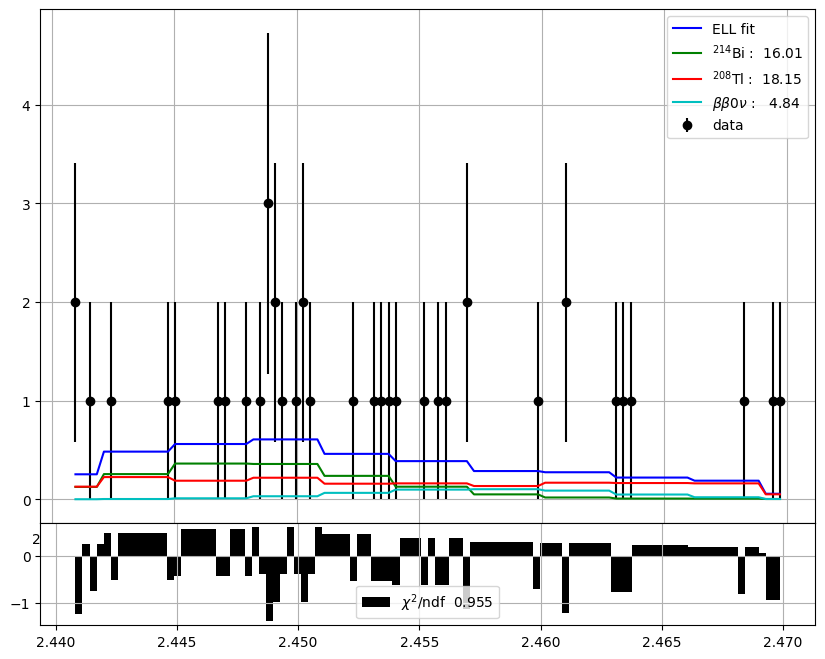

In [197]:
# --- Step 3: fit the simulated experiment ---
result_example, values_example, ell_example, _ = fit_example(mcdata_example)
n_est_example = result_example.x

print('\nComparison: expected vs estimated events in the energy window')
for name, expected, estimated in zip(sample_names, n_E_example, n_est_example):
    print('  {:2s}: expected = {:6.1f},  estimated = {:6.1f}'.format(name, expected, estimated))

# Plot the fit result
pltfn.plot_fit_ell(values_example, n_est_example, ell_example,
                    parnames=sample_names_latex)

Bi: n_est =  16.0  (-8.0, +7.7) at 68% CL
Tl: n_est =  18.2  (-8.5, +8.5) at 68% CL
bb: n_est =   4.8  (-4.4, +4.4) at 68% CL


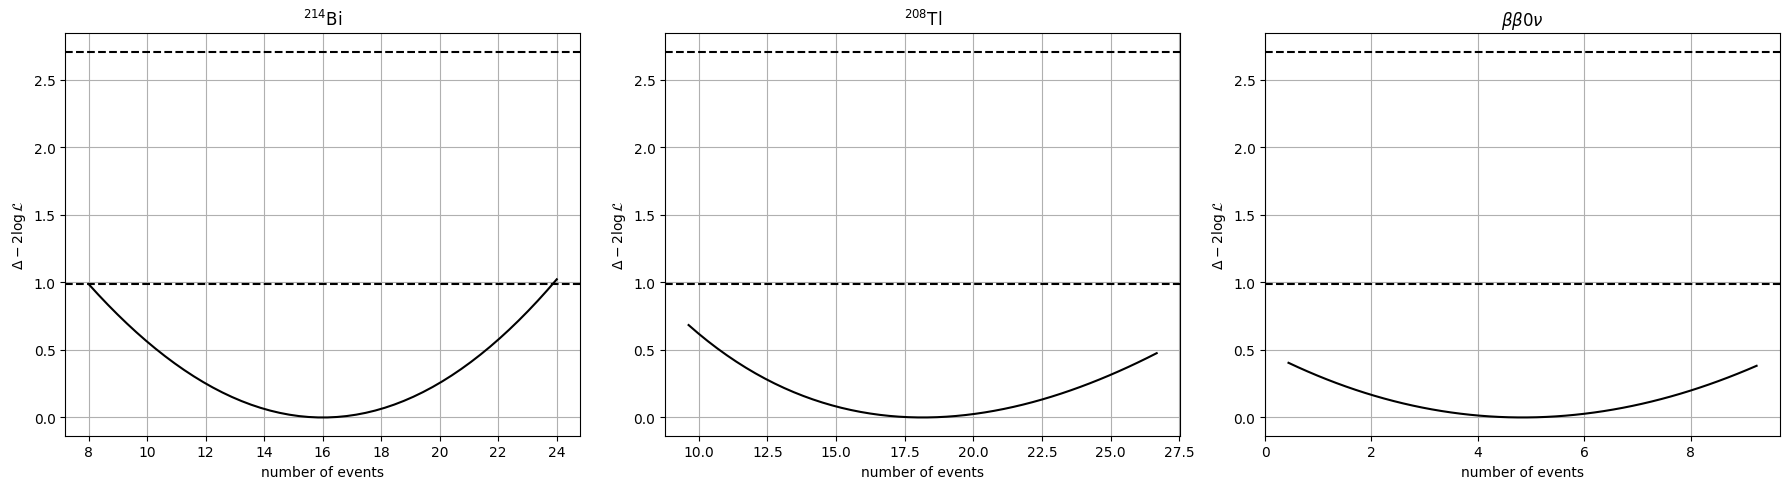

In [198]:
# --- Step 4: profile likelihood scan for uncertainties ---
nis_ex, tmus_ex = fn.tmu_scan(values_example, n_est_example, ell_example,
                               sizes=(2., 2., 2.))
pltfn.plot_tmu_scan(nis_ex, tmus_ex, titles=sample_names_latex)

cl = 0.68
mucis_ex = [efit.tmu_conf_int(ni, tmu, cl) for ni, tmu in zip(nis_ex, tmus_ex)]
for i, ci in enumerate(mucis_ex):
    print('{:s}: n_est = {:5.1f}  ({:+.1f}, {:+.1f}) at {:2.0f}% CL'.format(
        sample_names[i], n_est_example[i], *(ci - n_est_example[i]), 100*cl))

**Observations from the example:**
- The fit recovers the input number of events within the statistical uncertainties.
- The profile likelihood parabolas show the expected $\Delta(-2\log\mathcal{L}) = 1$ crossings.
- With a large signal, the $\beta\beta0\nu$ component is clearly visible in the energy spectrum.

---

### Now it is your turn

**Exercise**: Repeat the procedure above with different signal strengths.
Try `factor = 0.5, 0.1, 0.0` to see how the fit behaves when the signal becomes small or absent.
In particular, study:
- How well does the fit recover the true number of signal events?
- What happens to the uncertainties as the signal shrinks?
- Can the fit distinguish signal from background when the signal is very small?

**Exercise**

  * Generate other experiments with different number of signal events to study the performance of the fit

In [199]:
# Set the expected number of events for each sample (Bi, Tl, bb) in the energy window.
# For example:
#   nbb_trial = 5  # trial number of signal events
#   n_total = [n_Bi_total, n_Tl_total, nbb_trial]  (total events per sample)
#   n_E     = [n_Bi_total * eff_Bi_E, n_Tl_total * eff_Tl_E, nbb_trial * eff_bb_E]
# YOUR CODE HERE


In [200]:

# filename = '/data/fanal_' + coll + '.h5'

# mcbb       = pd.read_hdf(rootpath + filename, key = 'mc/bb0nu').fillna(0.)   # MC Tl
# print('Data path and filename : ', rootpath + filename)

# def efficiency(mask):
#     return float(sum(mask)/len(mask))

# data_blind = pd.read_hdf(rootpath + filename, key = 'data/blind').fillna(0.) # blind data
# mask_bb = fn.selection_blind(mcbb)
# eff_bb_blind = efficiency(mask_bb)
# mc_blind_samples =  (mcbb[mask_bb])

# nguess = (1000.)
# varname   = 'E'
# refnames  = (varname) 
# refranges = (sel_erange)

# fit        = fn.prepare_fit_ell(mc_blind_samples, nguess, refnames, refranges)

# result, enes, ell, _ = fit(data_blind)
# nevts_blind          = result.x

# pltfn.plot_fit_ell(enes, nevts_blind, ell, parnames = sample_names_latex);

# result, enes, ell, _ = fit(data_blind)
# nevts_blind          = result.x
# n_bb_blind = nevts_blind[0]
# n_bb_total = n_bb_blind / eff_bb_blind


In [201]:
# --- Step 1: define event numbers ---
# We choose a large signal: as many bb events in the RoI as Bi events
# (this makes the signal clearly visible in the fit)


def define_event_numbers(n_bb_total_trial):
    n_Bi_total = collpars.n_Bi_total
    n_Tl_total = collpars.n_Tl_total
                  
    n_bb_RoI_trial  = collpars.eff_bb_RoI * n_bb_total_trial  

    # Total events per sample
    n_total = np.array([n_Bi_total, n_Tl_total, n_bb_total_trial])

    # Expected events in the energy window (after selection)
    n_E = np.array([n_Bi_total * eff_Bi_E,
                            n_Tl_total * eff_Tl_E,
                            n_bb_total_trial * eff_bb_E])

    for name, nt, ne in zip(sample_names, n_total, n_E):
        print('  {:2s}: n_total = {:8.1f},  n_E = {:6.1f}'.format(name, nt, ne))


    fit = fn.prepare_fit_ell(mc_samples, n_total_example,
                                    varnames, varranges, refnames, refranges)

        
    # generate_mc_experiment samples events from each MC template
    # with Poisson-fluctuated counts around n_total_example
    mcdata = fn.generate_mc_experiment(mc_samples, n_total)

    # --- Step 3: fit the simulated experiment ---
    result, values, ell, _ = fit_example(mcdata)
    n_est = result.x

    print('\nComparison: expected vs estimated events in the energy window')
    for name, expected, estimated in zip(sample_names, n_E, n_est):
        print('  {:2s}: expected = {:6.1f},  estimated = {:6.1f}'.format(name, expected, estimated))

        

    # Plot the fit result
    pltfn.plot_fit_ell(values, n_est, ell,
                        parnames=sample_names_latex)

    


    nis_ex, tmus_ex = fn.tmu_scan(values, n_est, ell,
                                sizes=(2., 2., 2.))
    pltfn.plot_tmu_scan(nis_ex, tmus_ex, titles=sample_names_latex)

    cl = 0.68
    mucis_ex = [efit.tmu_conf_int(ni, tmu, cl) for ni, tmu in zip(nis_ex, tmus_ex)]
    for i, ci in enumerate(mucis_ex):
        print('{:s}: n_est = {:5.1f}  ({:+.1f}, {:+.1f}) at {:2.0f}% CL'.format(
            sample_names[i], n_est[i], *(ci - n_est[i]), 100*cl))

    print("=="*30)
    return n_total, n_E, mcdata, result, values, ell, n_est


FACTOR = 0.0 

  Bi: n_total =   1184.9,  n_E =   16.6
  Tl: n_total =   3729.6,  n_E =    0.4
  bb: n_total =      0.0,  n_E =    0.0

Comparison: expected vs estimated events in the energy window
  Bi: expected =   16.6,  estimated =   11.5
  Tl: expected =    0.4,  estimated =    0.0
  bb: expected =    0.0,  estimated =    2.5
Bi: n_est =  11.5  (-3.5, +4.0) at 68% CL
Tl: n_est =   0.0  (+0.0, +3.3) at 68% CL
bb: n_est =   2.5  (-2.0, +2.8) at 68% CL
FACTOR = 5.2631578947368425 

  Bi: n_total =   1184.9,  n_E =   16.6
  Tl: n_total =   3729.6,  n_E =    0.4
  bb: n_total =      5.3,  n_E =    2.7

Comparison: expected vs estimated events in the energy window
  Bi: expected =   16.6,  estimated =   13.7
  Tl: expected =    0.4,  estimated =    2.3
  bb: expected =    2.7,  estimated =    0.0
Bi: n_est =  13.7  (-4.4, +4.7) at 68% CL
Tl: n_est =   2.3  (-2.3, +3.0) at 68% CL
bb: n_est =   0.0  (+0.0, +3.3) at 68% CL
FACTOR = 10.526315789473685 

  Bi: n_total =   1184.9,  n_E =   16

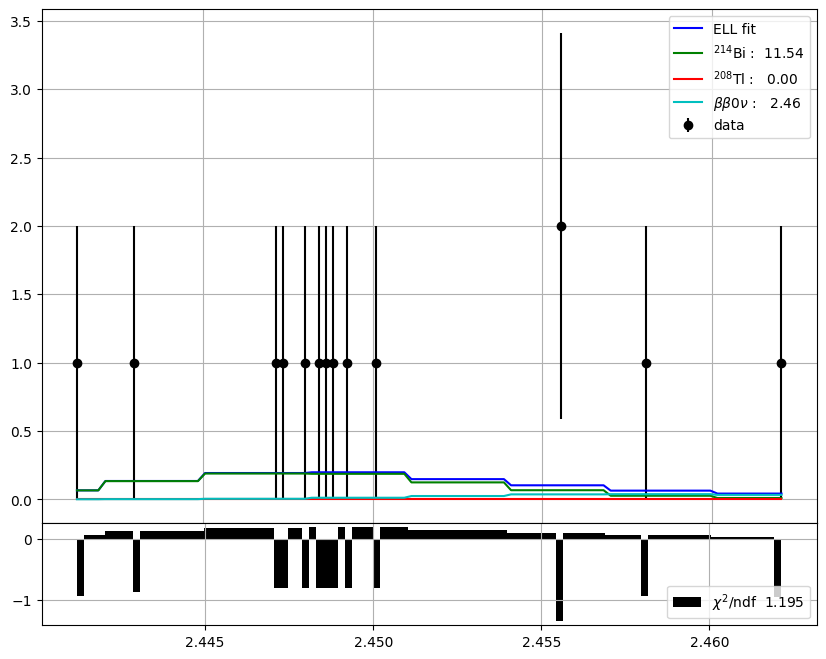

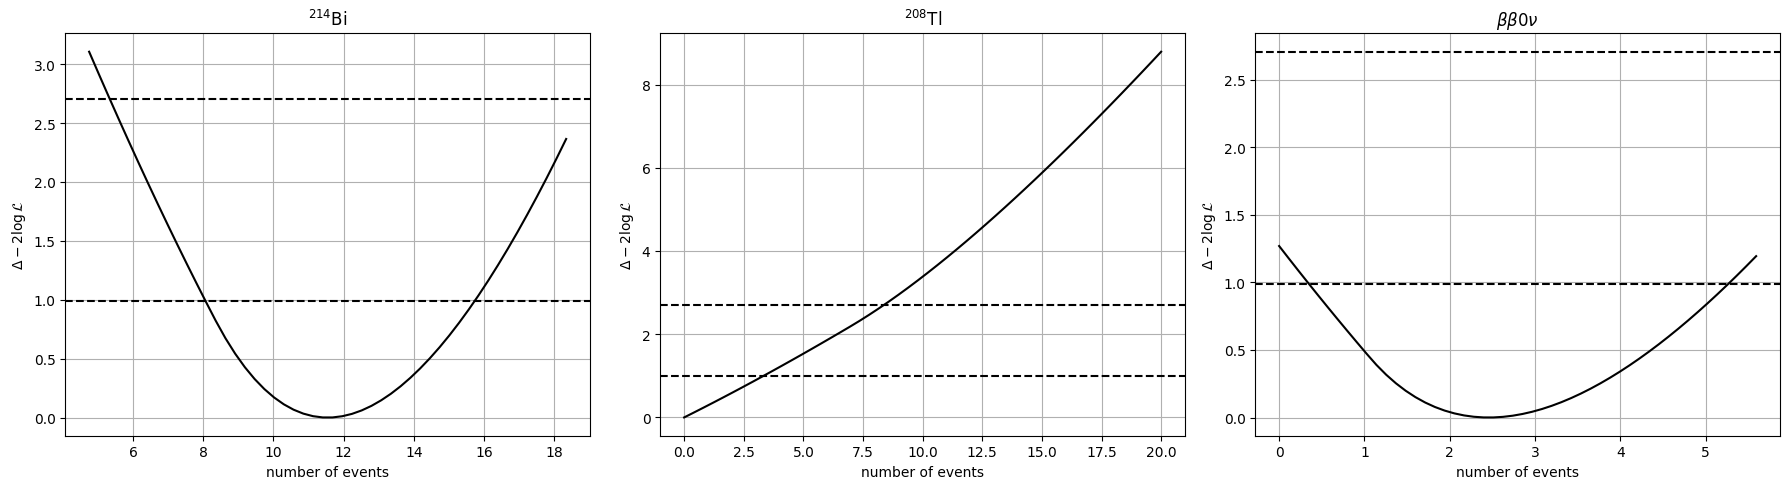

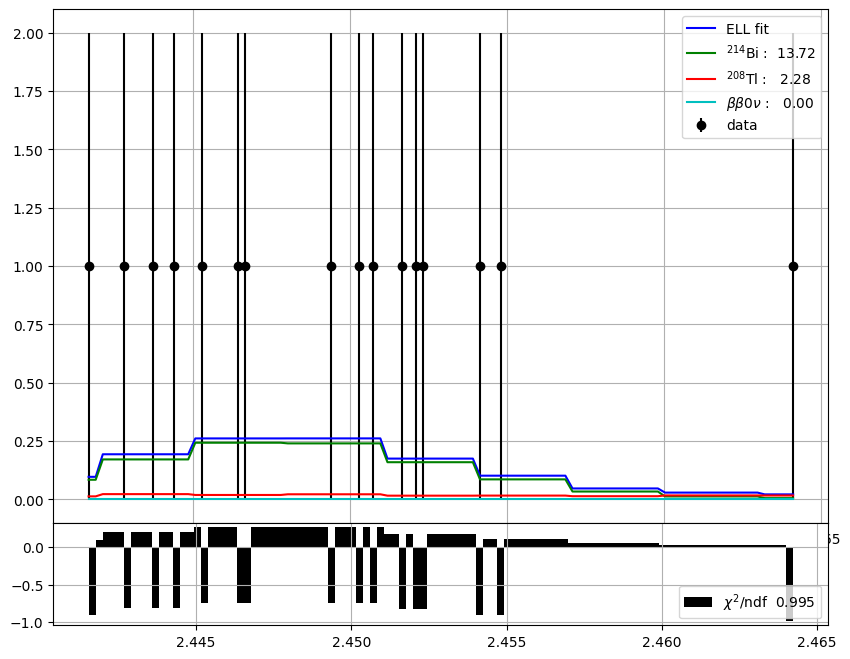

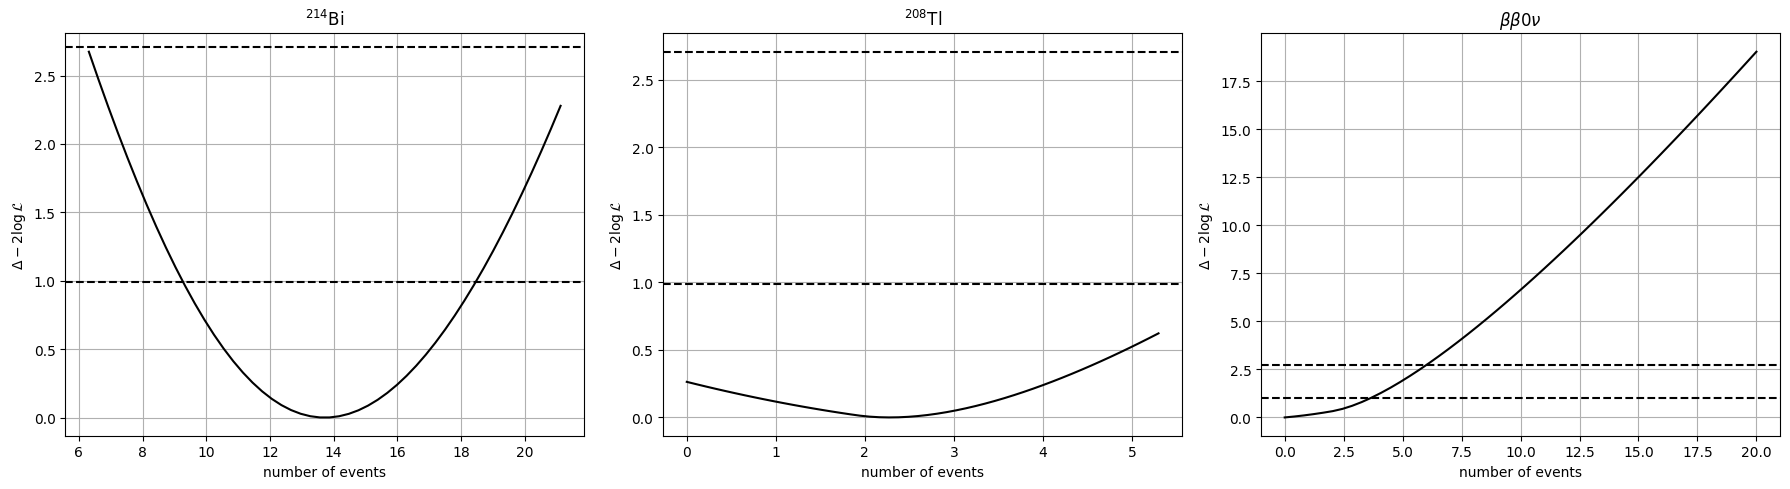

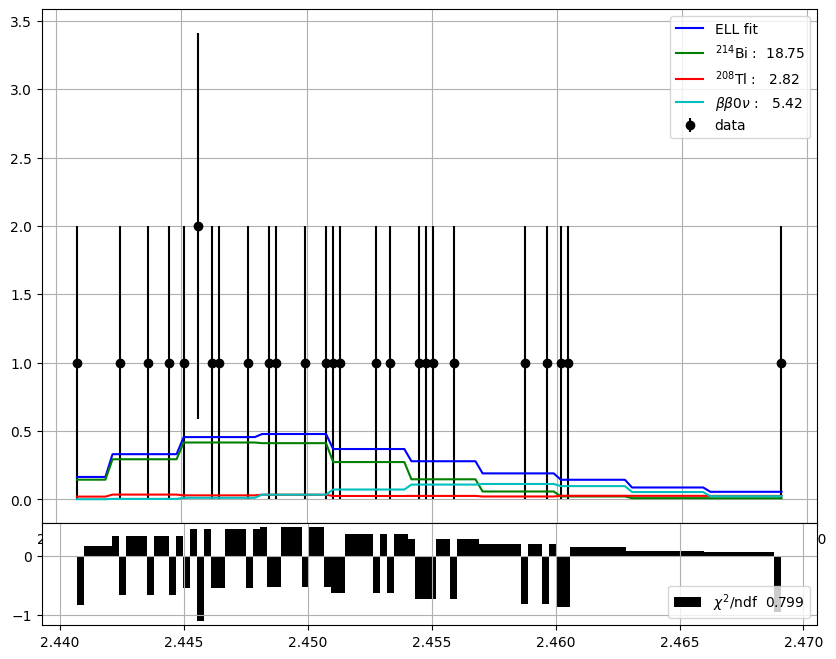

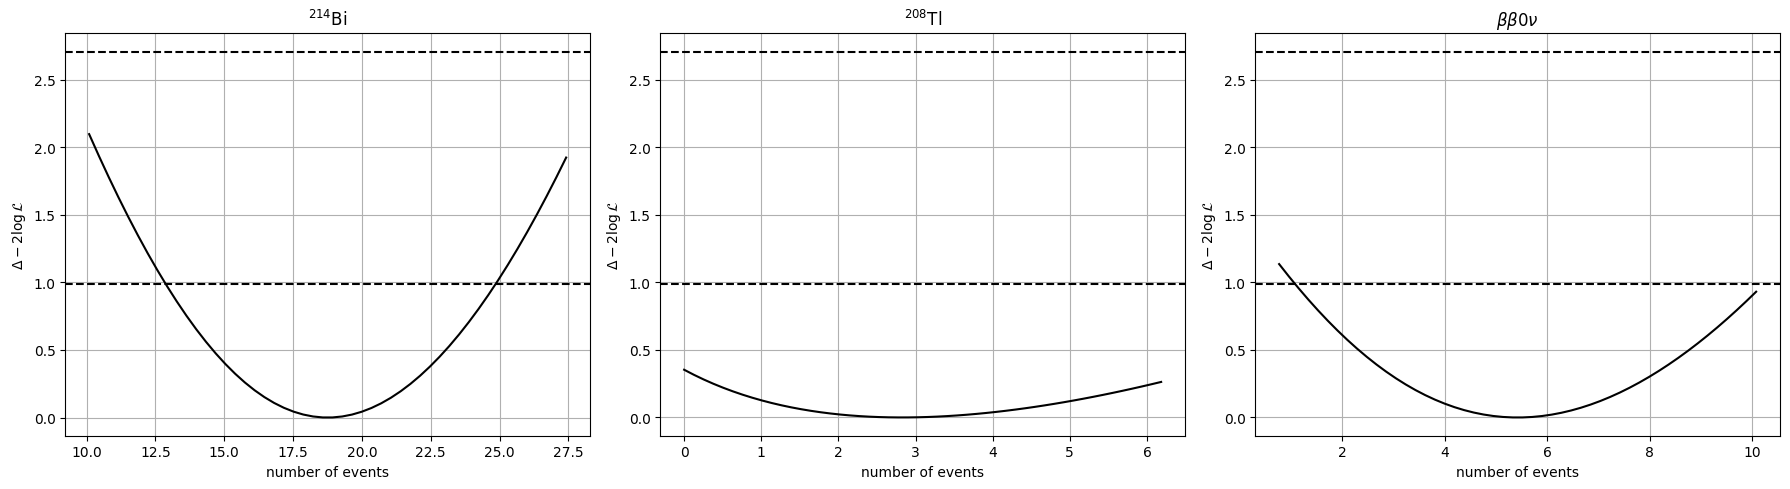

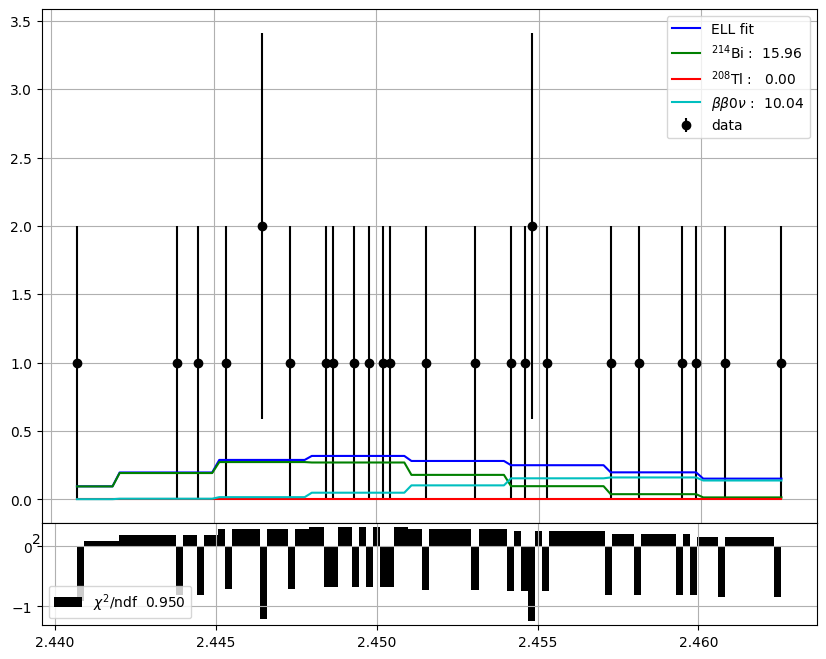

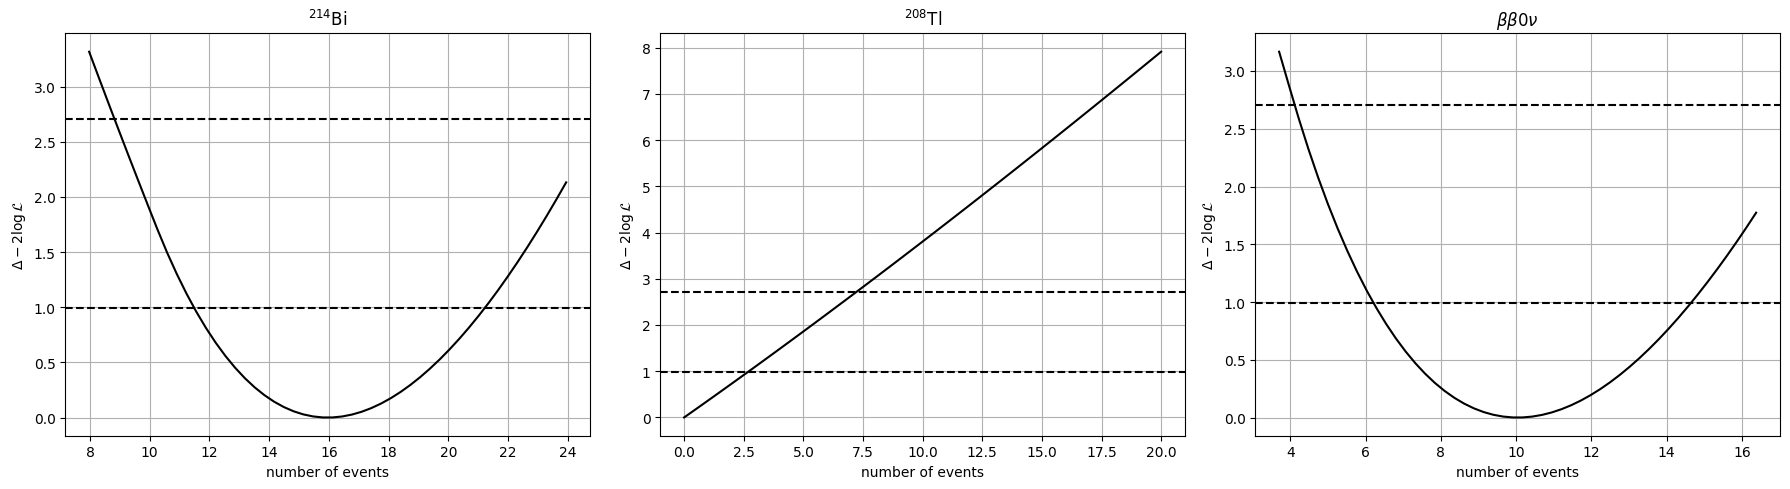

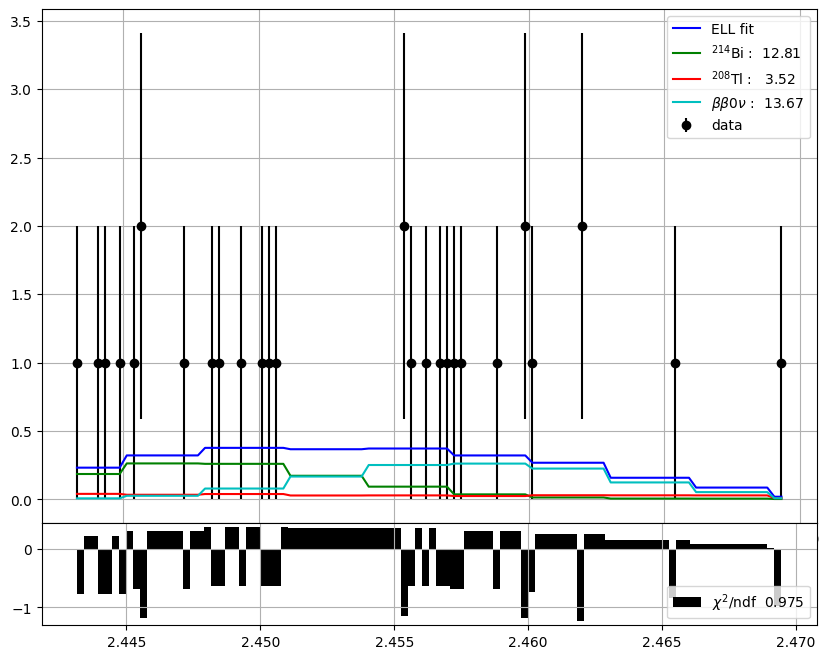

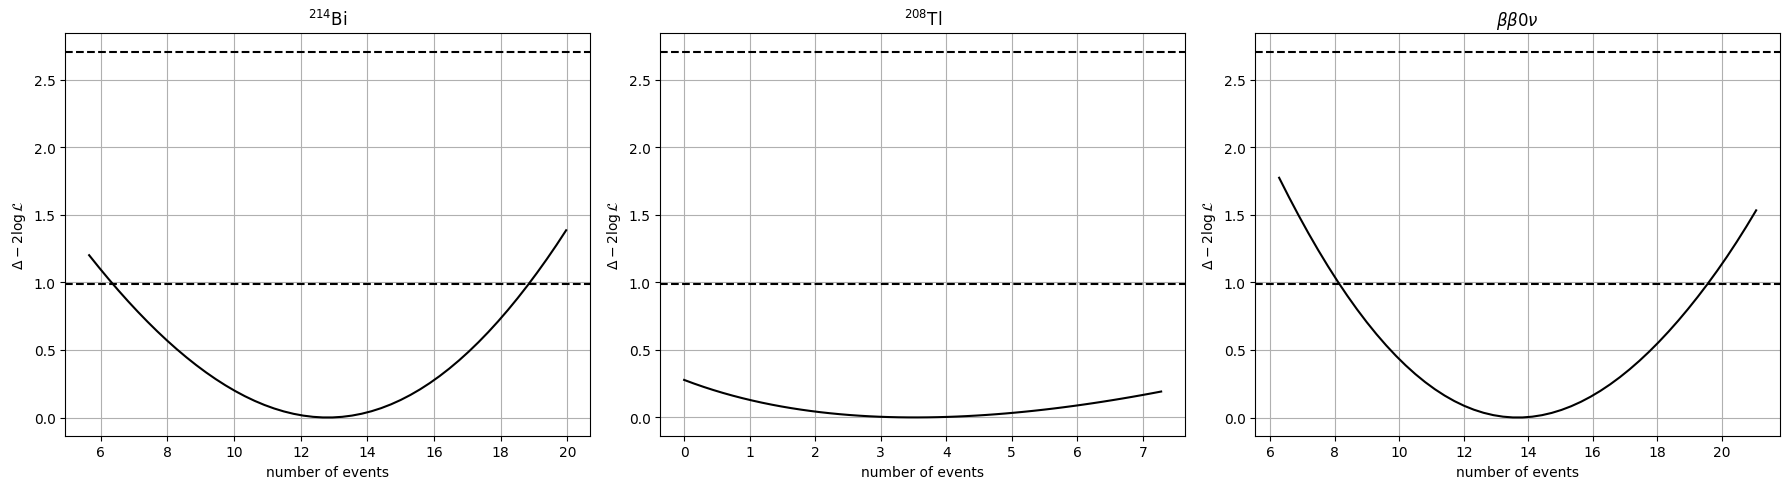

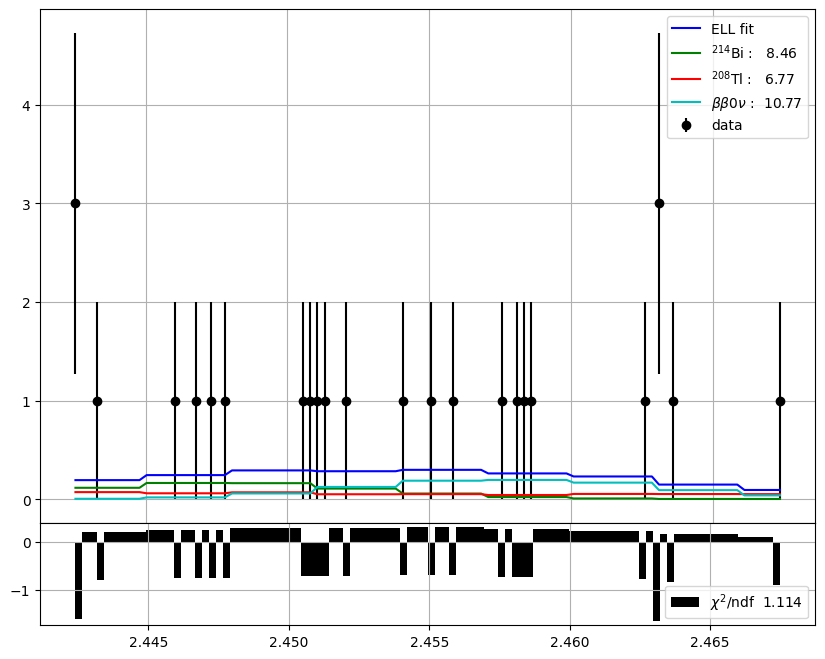

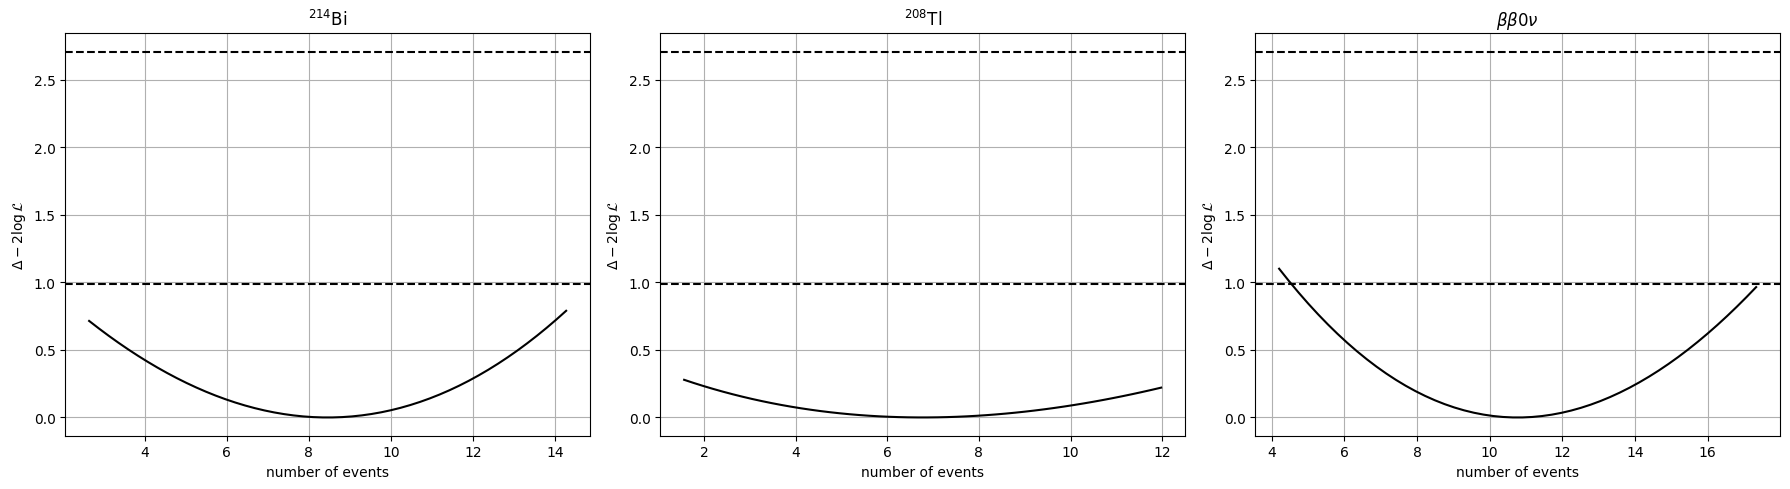

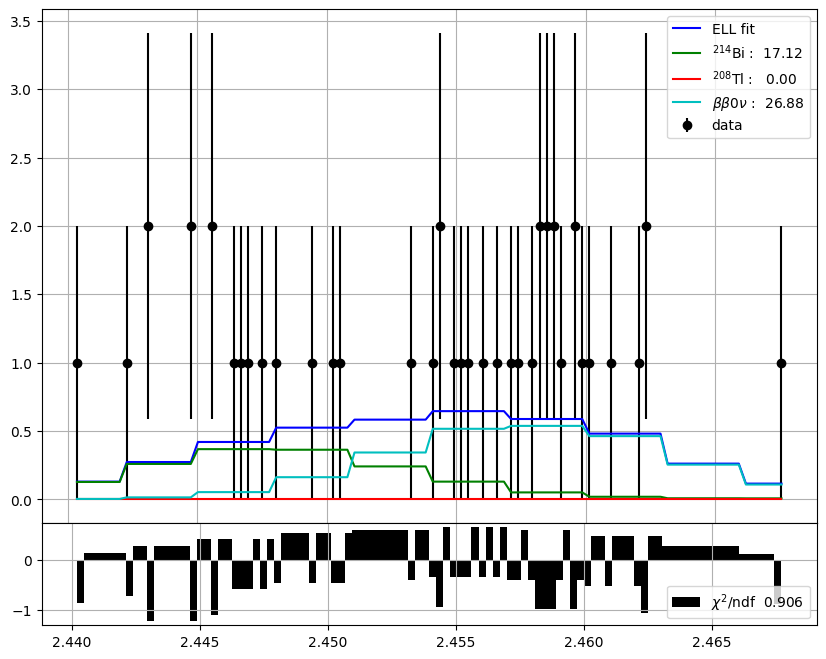

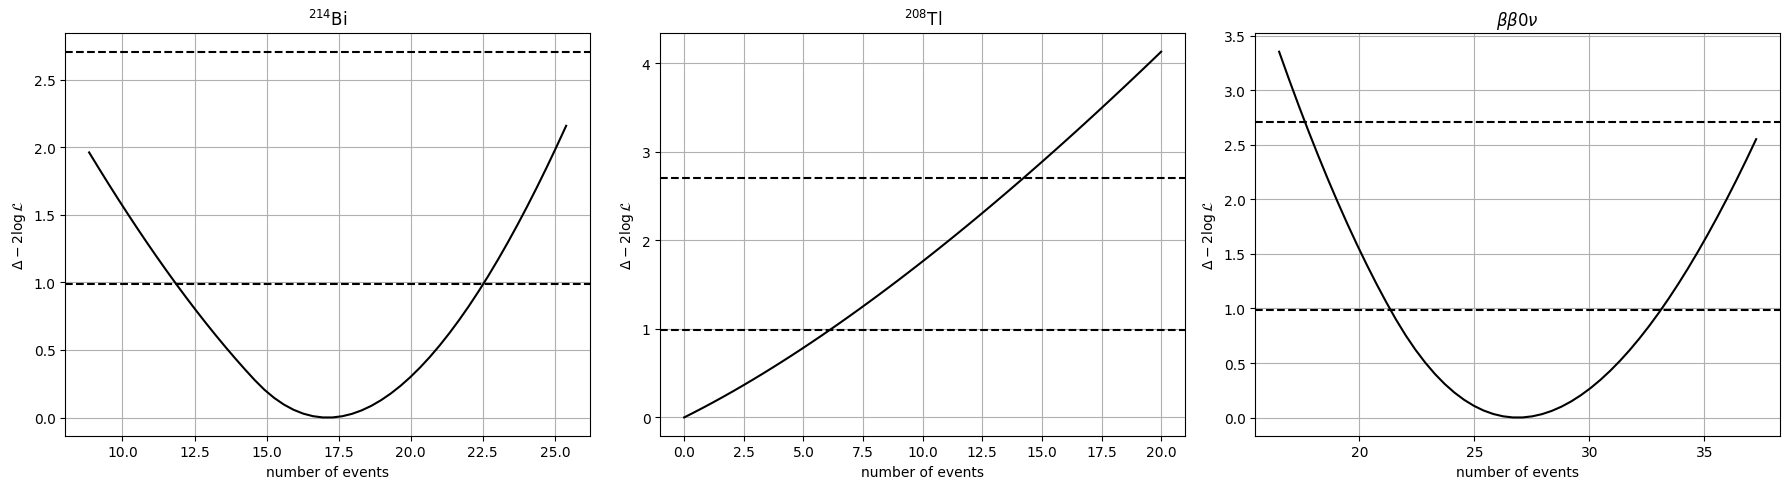

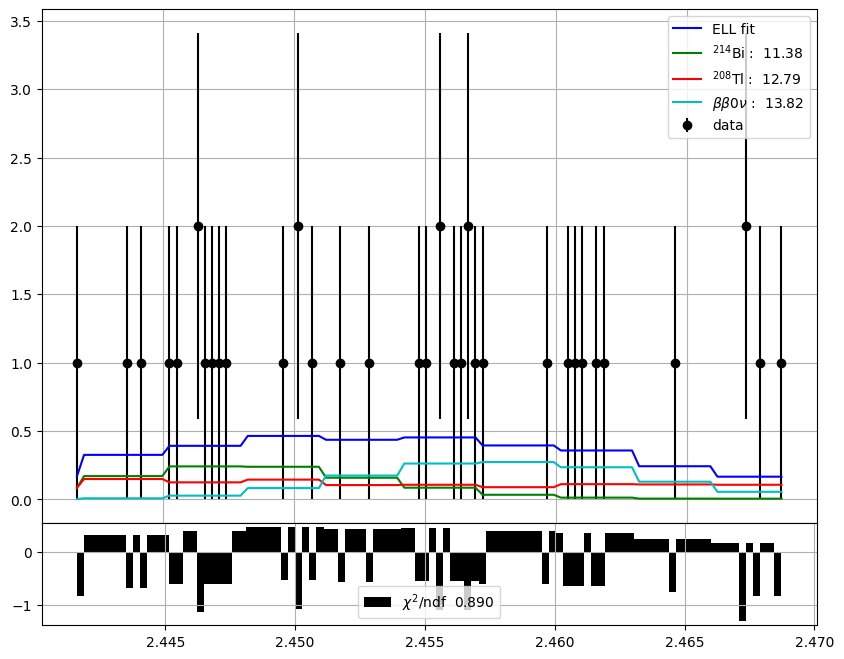

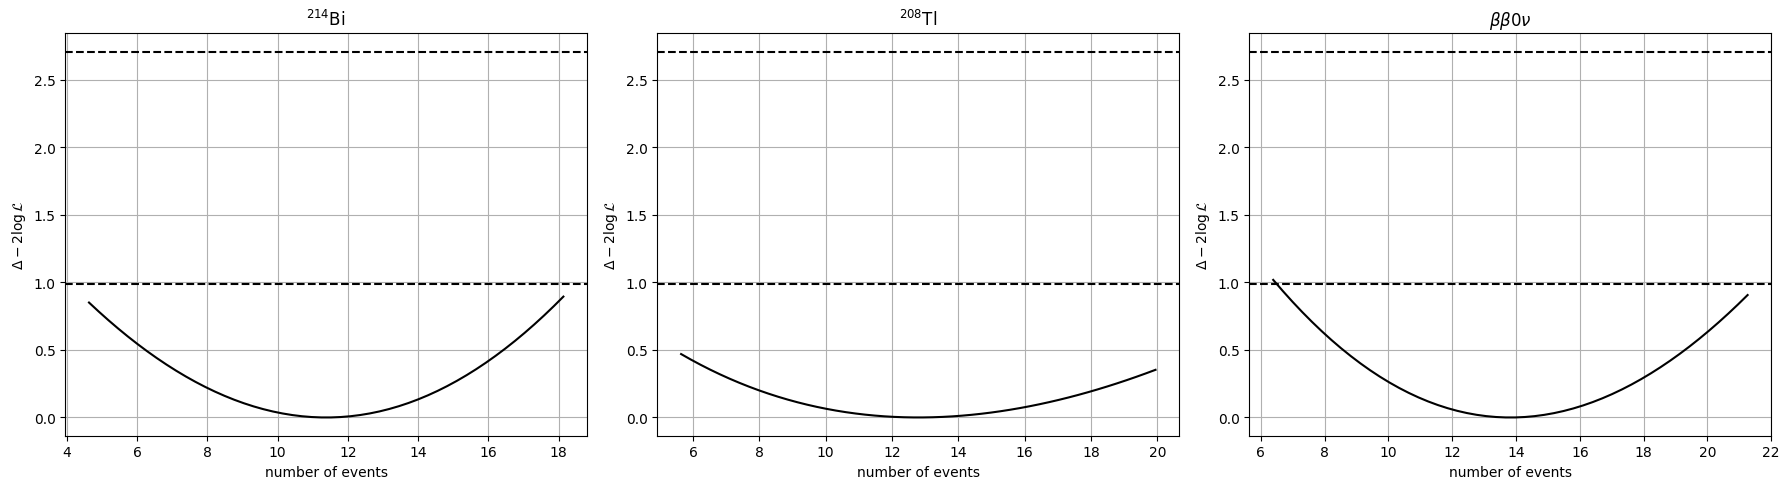

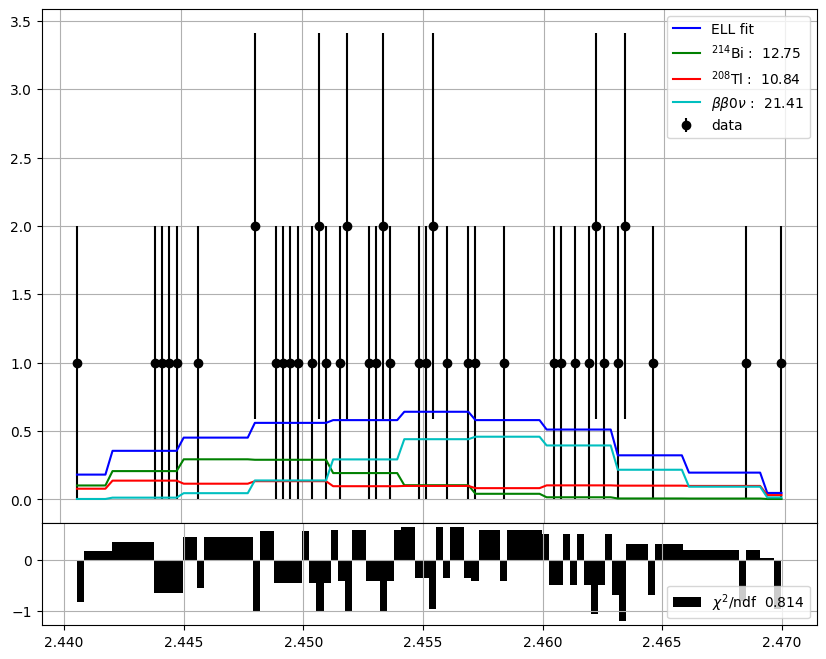

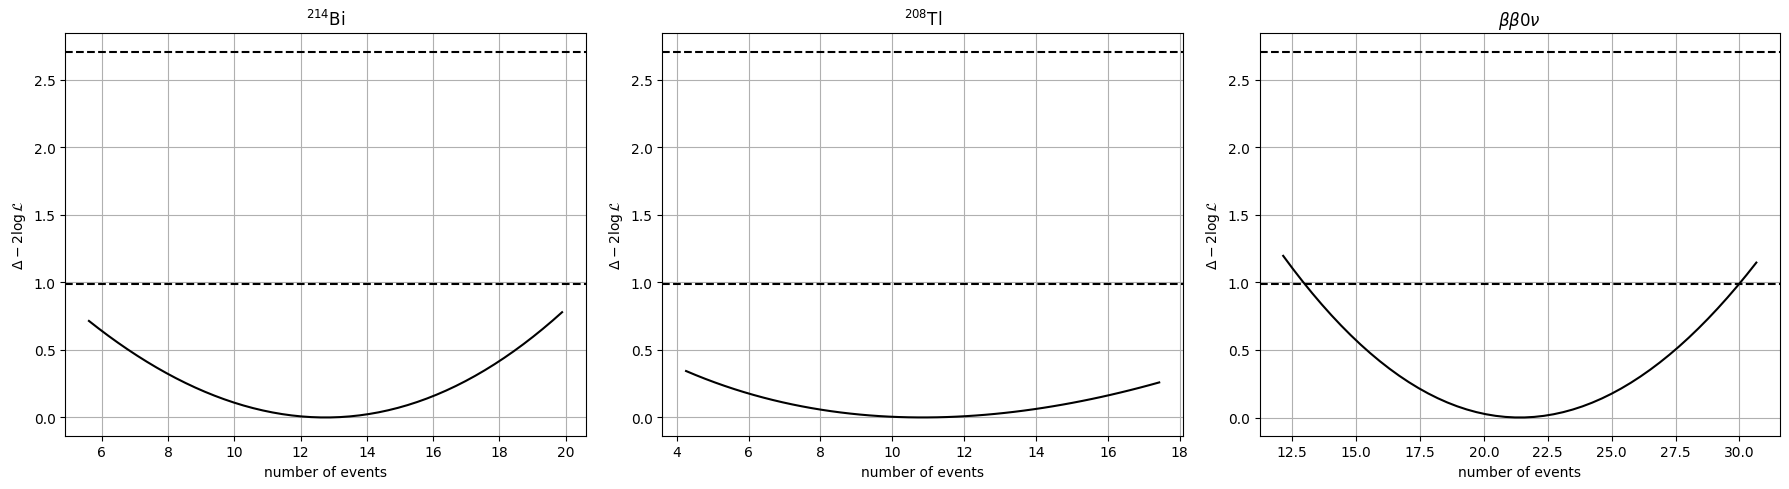

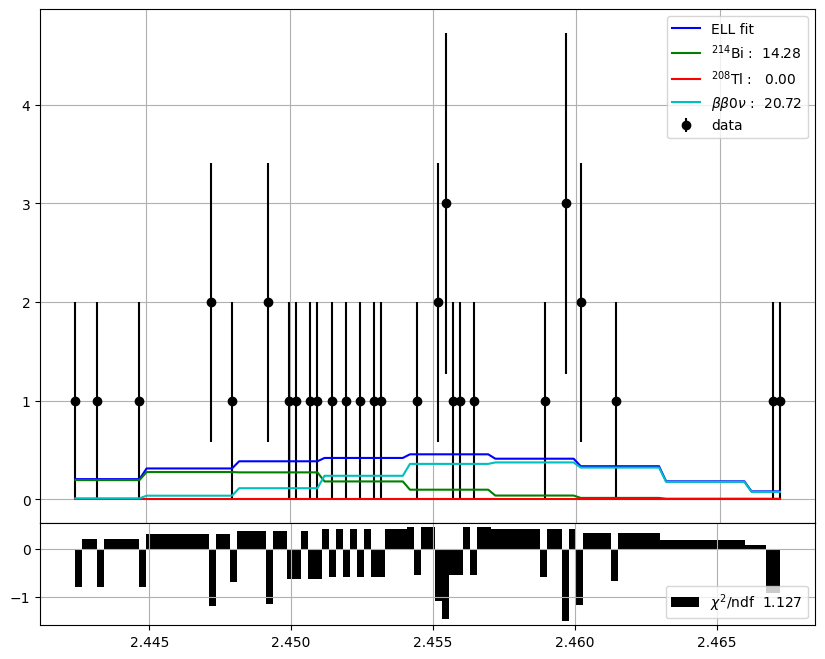

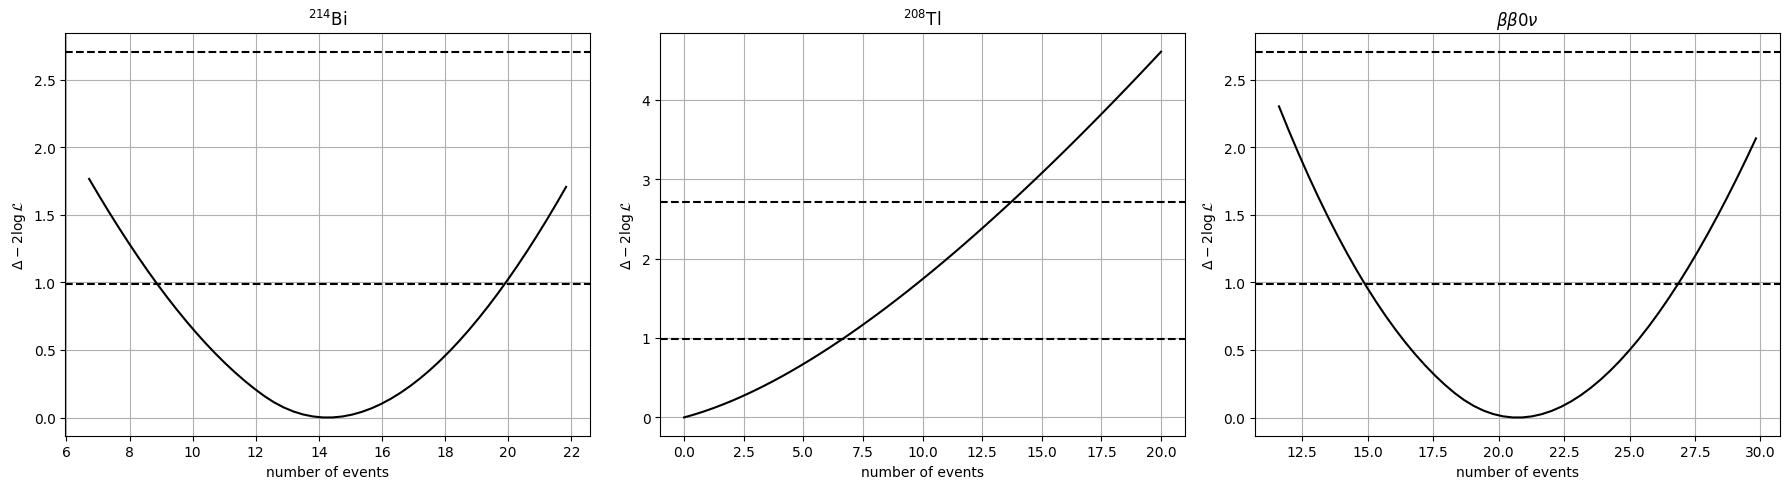

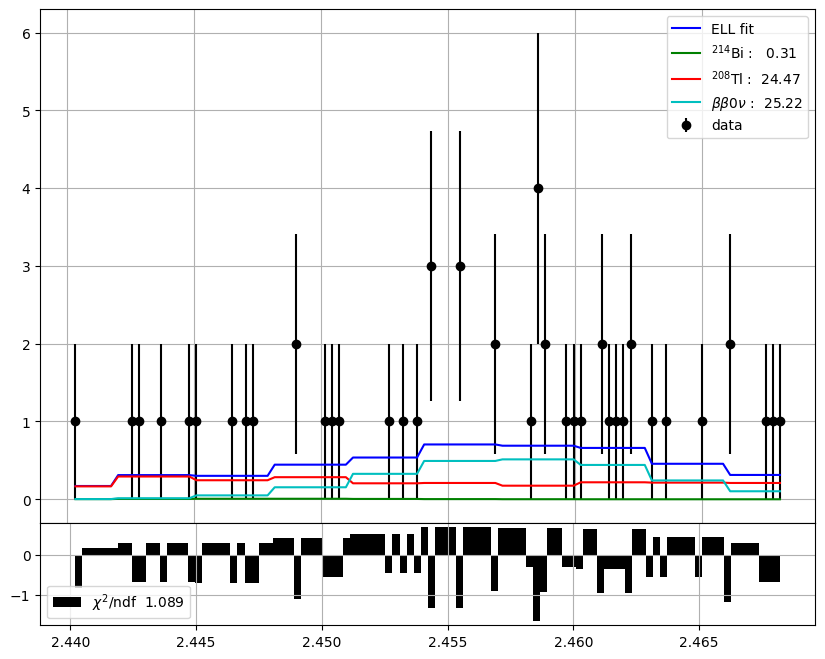

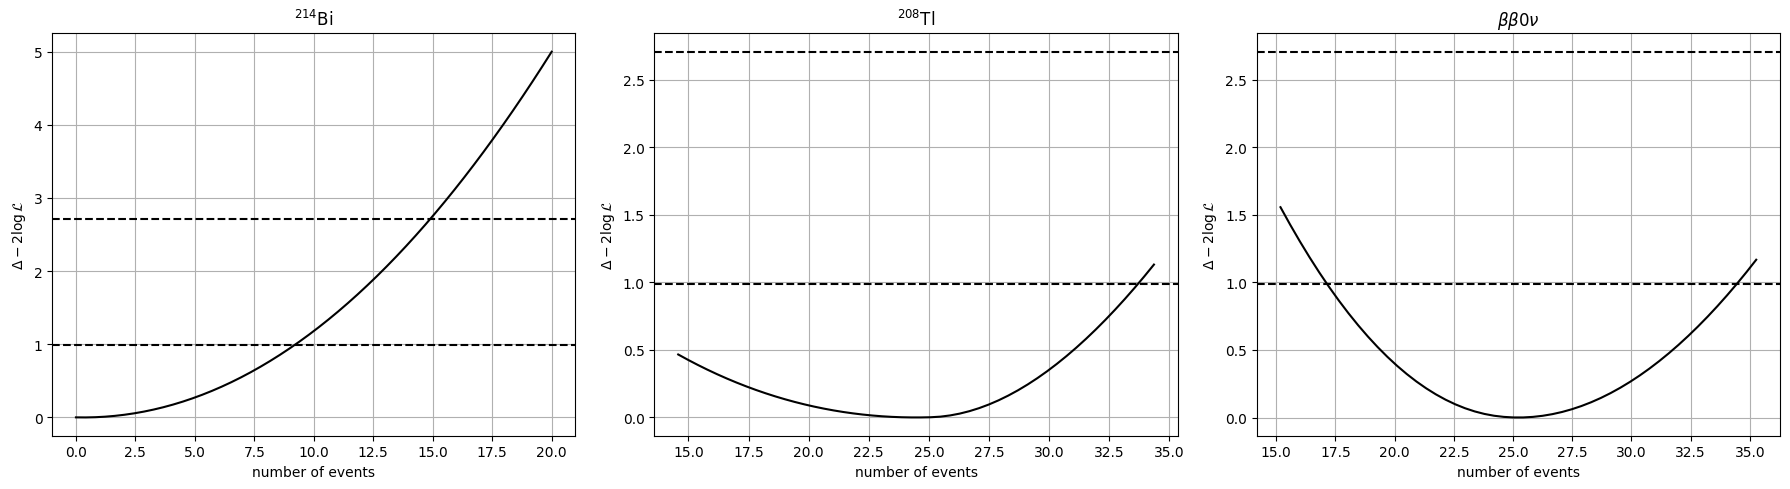

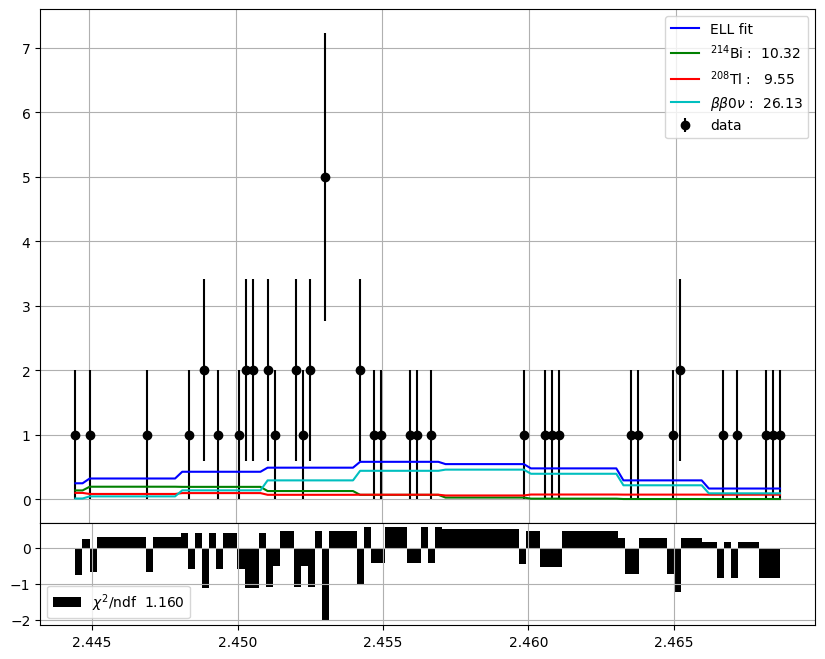

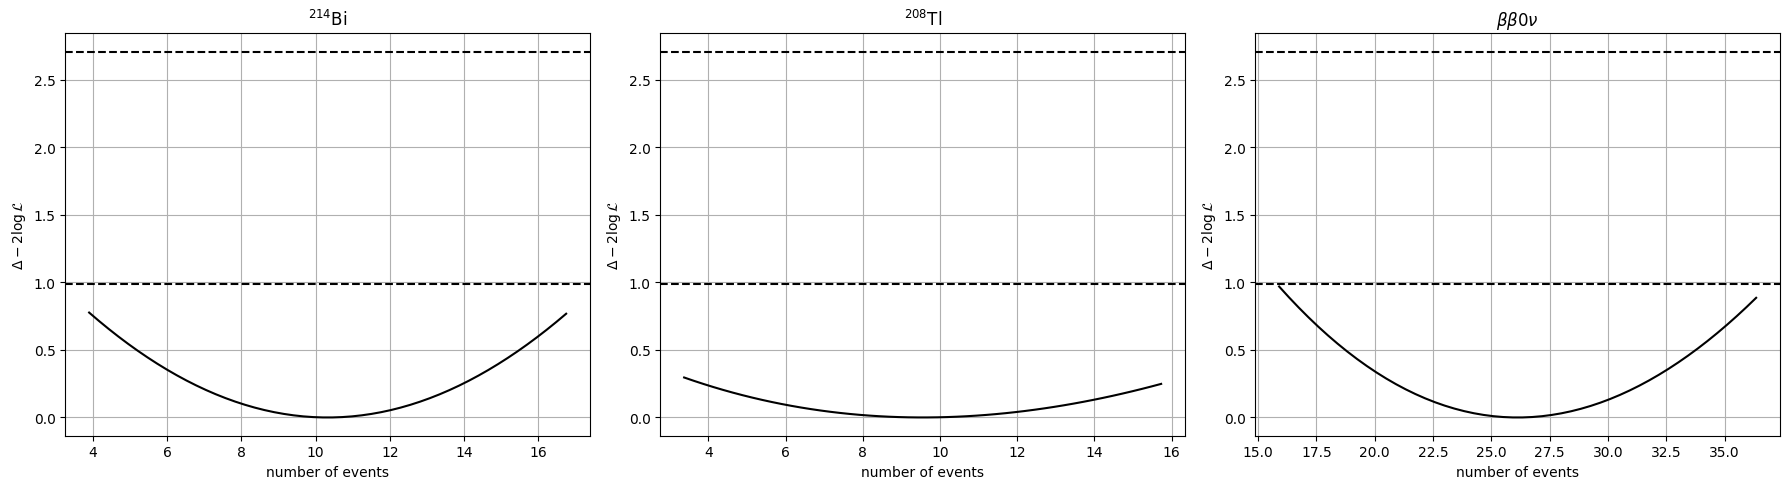

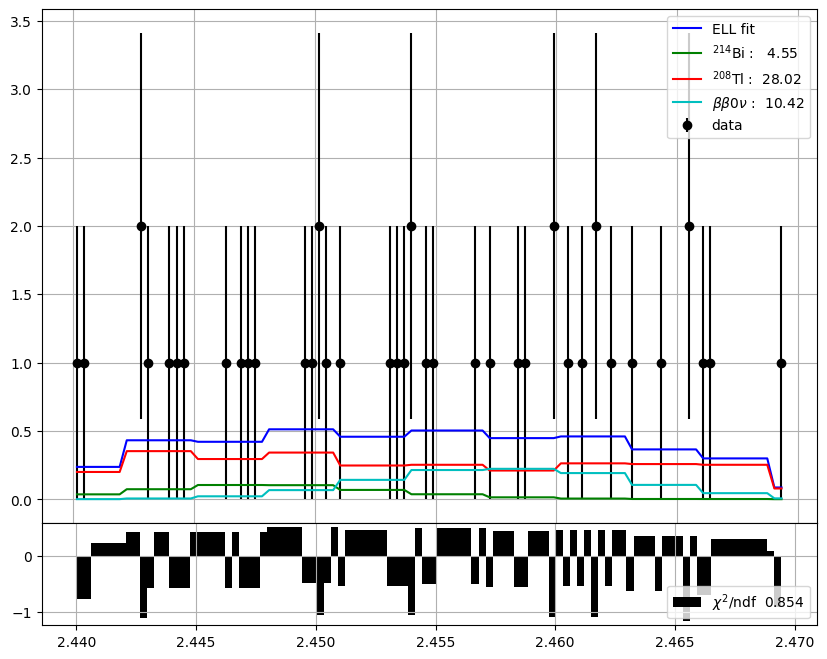

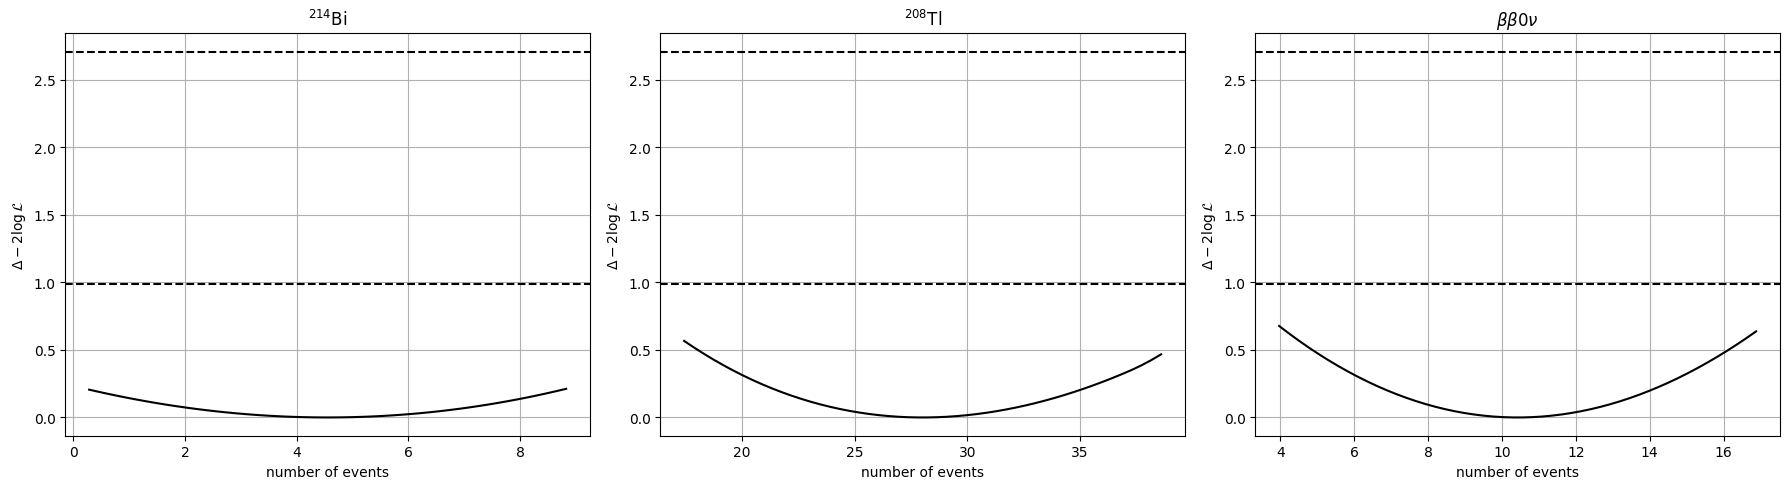

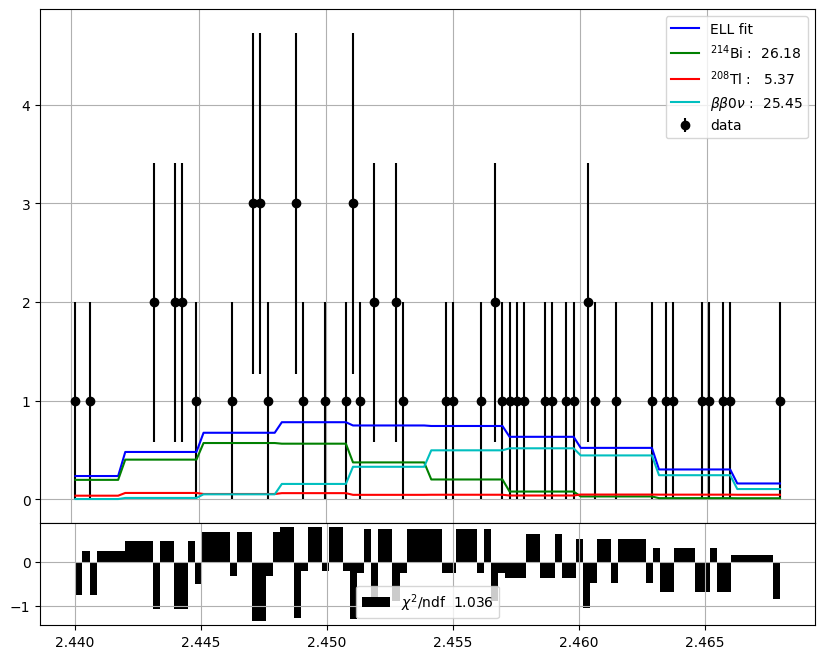

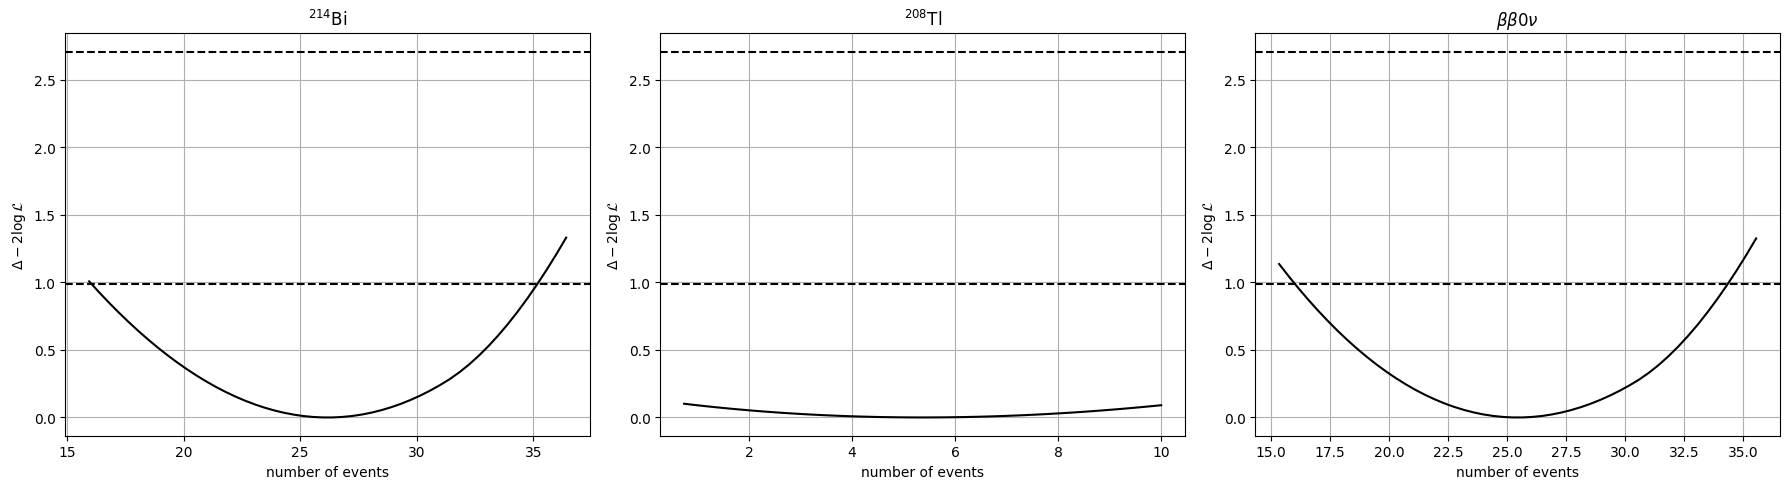

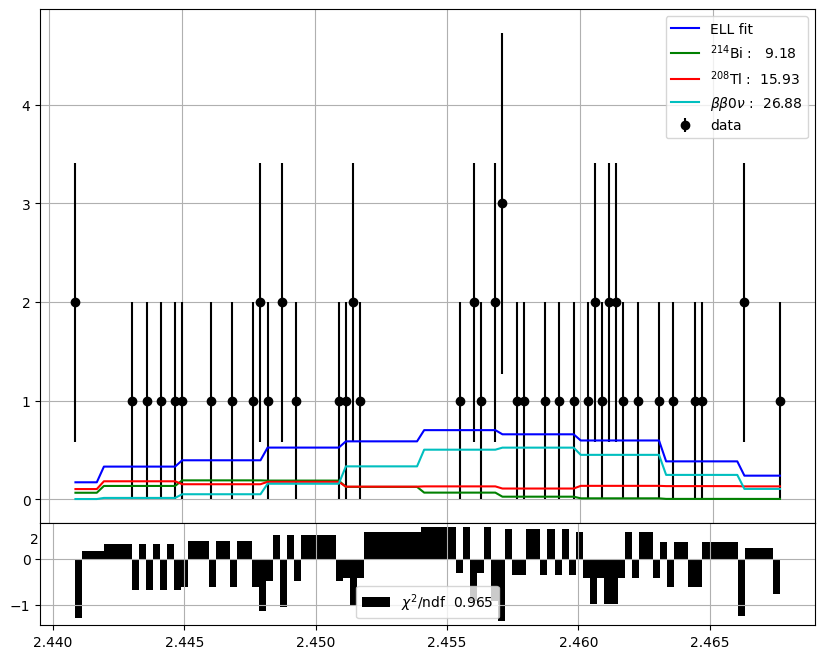

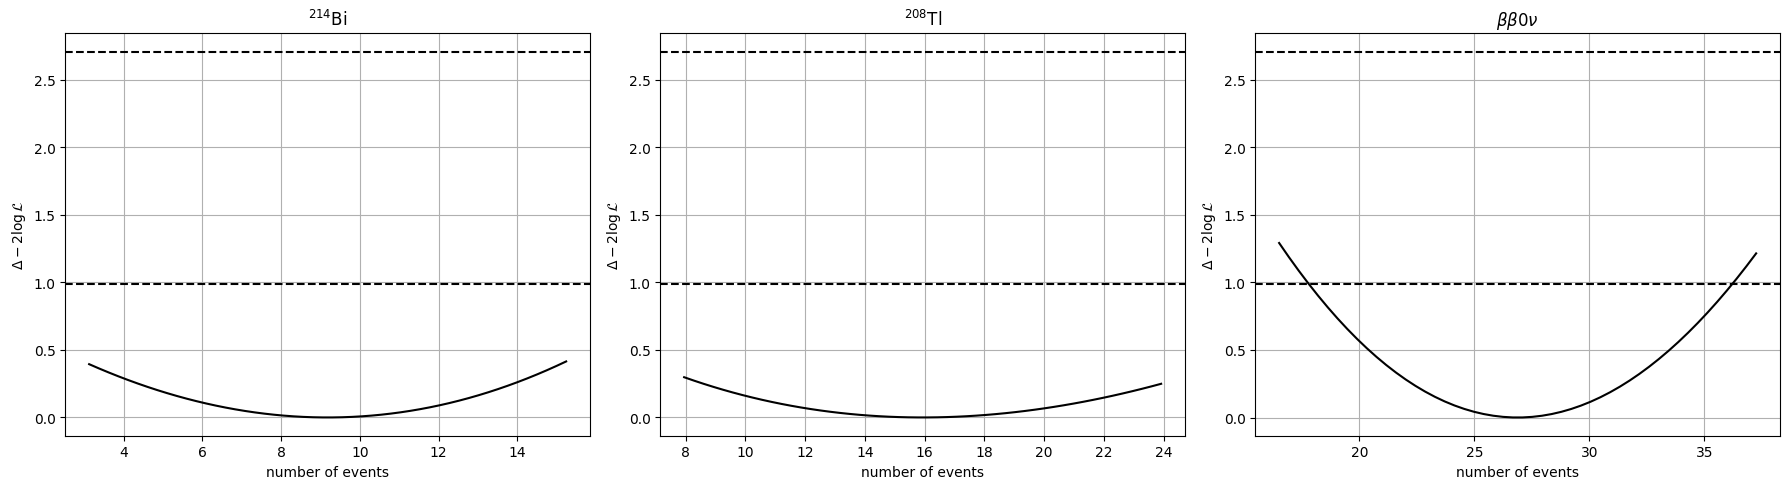

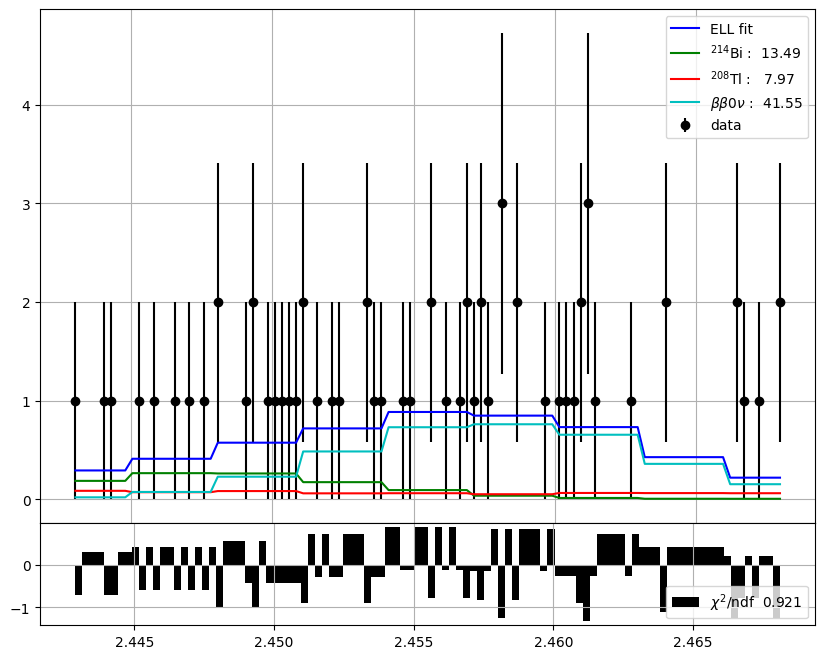

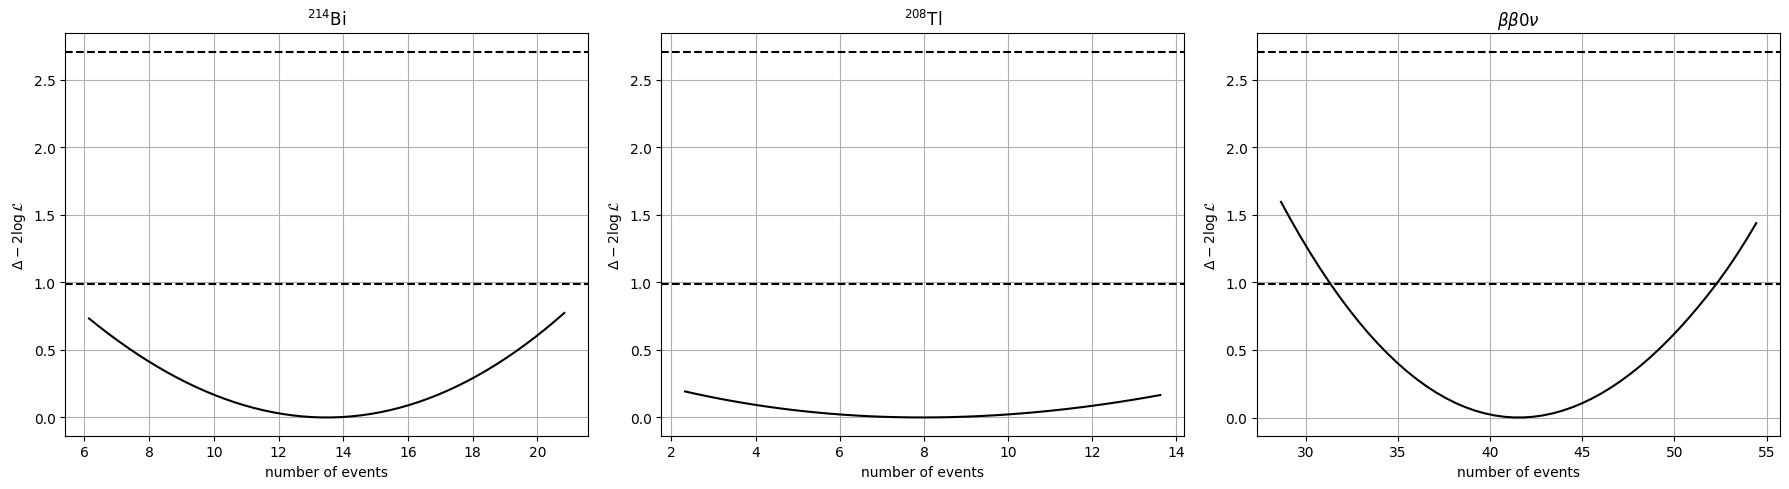

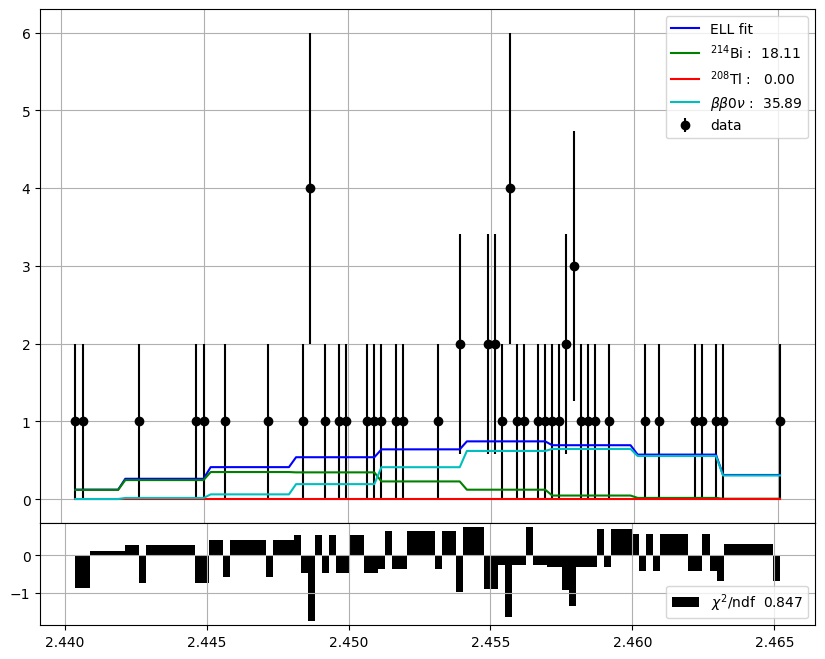

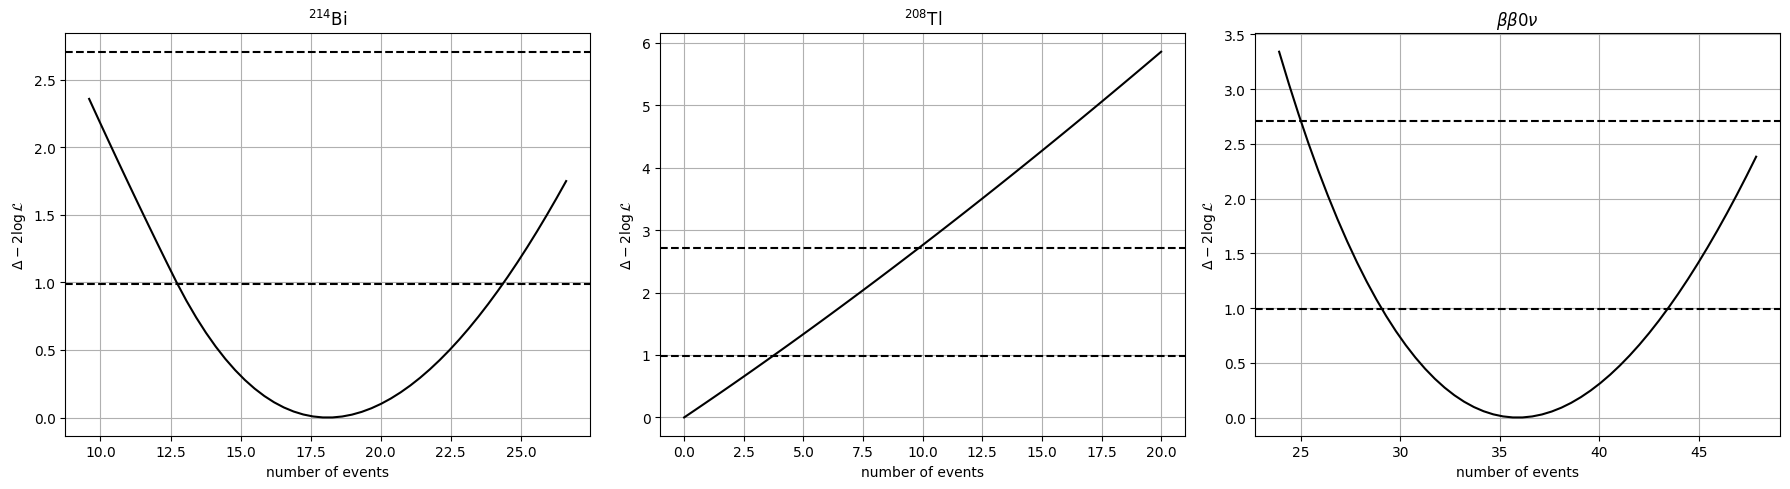

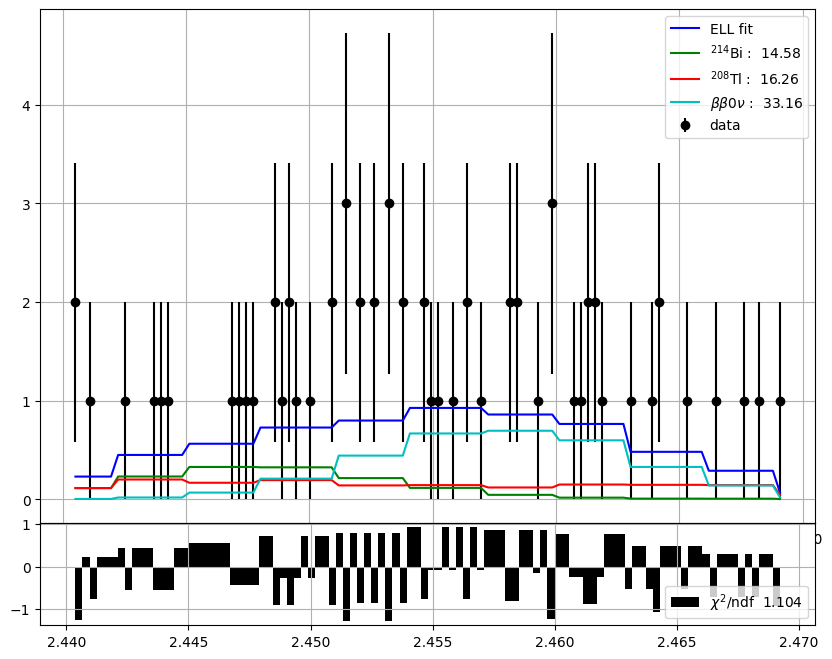

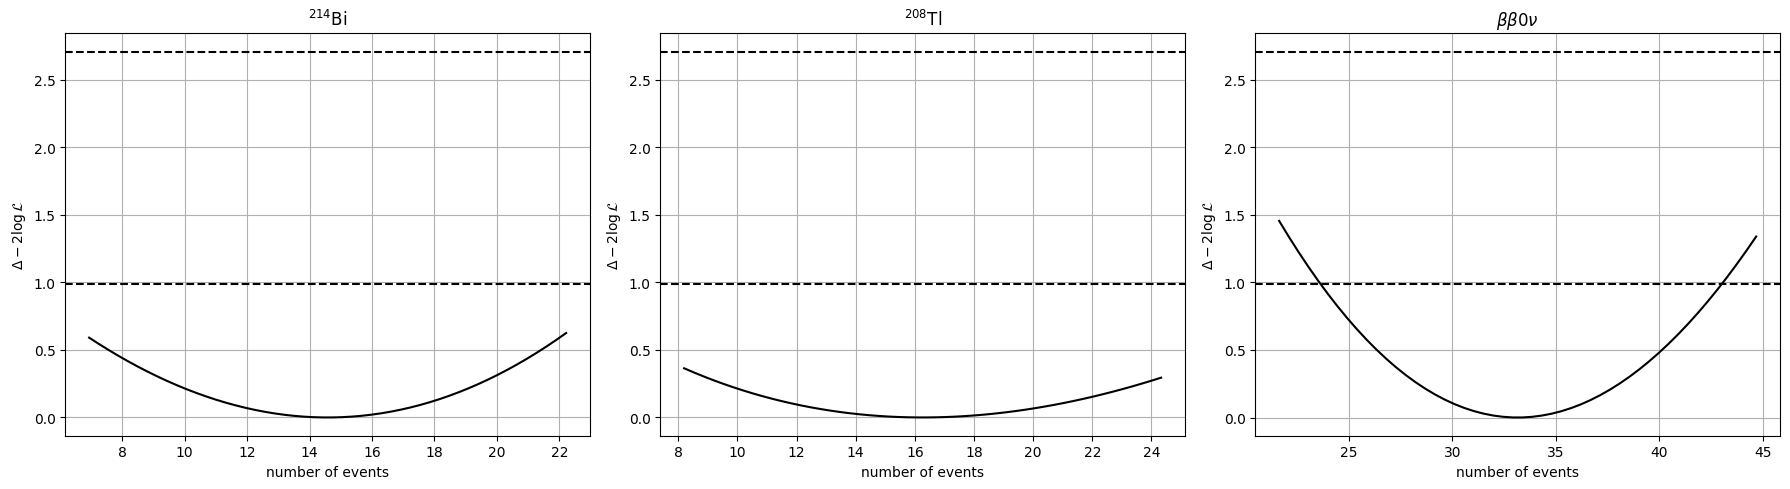

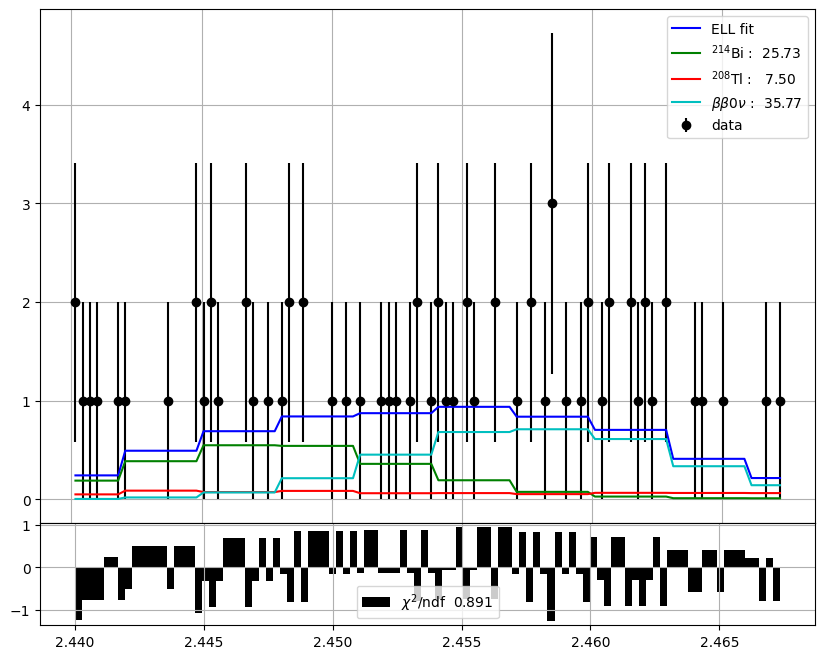

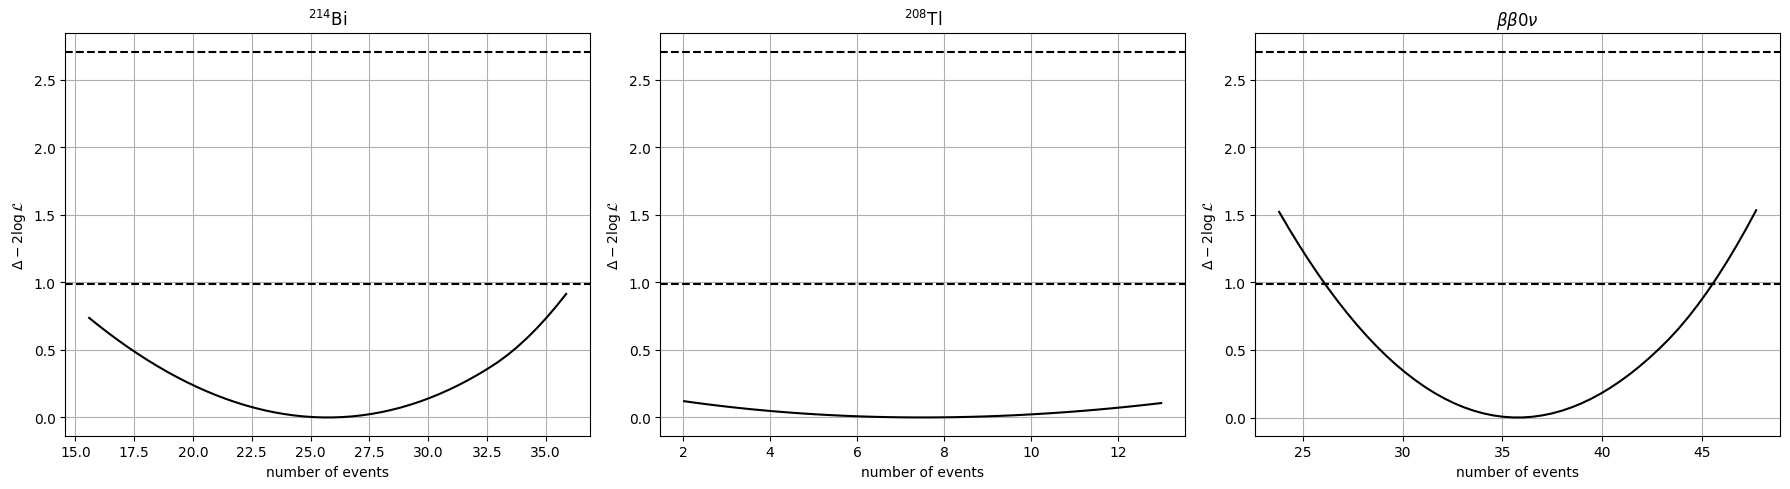

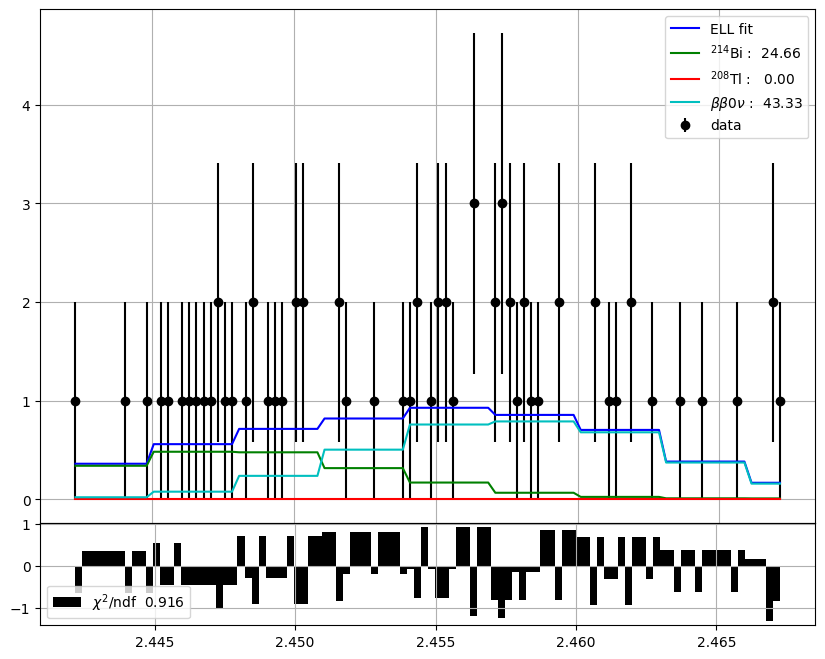

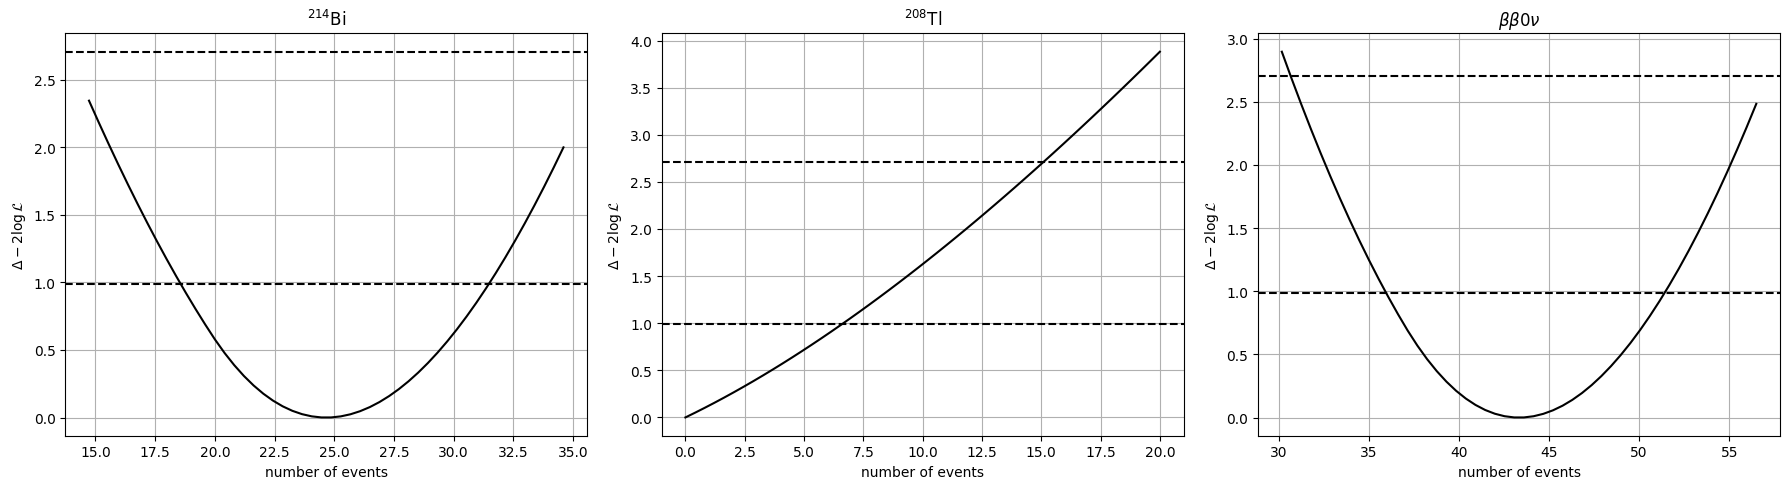

In [202]:
factors = np.linspace(0.0,100,20)

n_total_rows = []
n_E_rows     = []
n_est_rows   = []

mcdata_list = []
result_list = []
values_list = []
ell_list    = []

for factor in factors:
    print(f"FACTOR = {factor} \n")
    nt, ne, mc, res, val, el, nest = define_event_numbers(factor)

    n_total_rows.append(nt)
    n_E_rows.append(ne)
    n_est_rows.append(nest)

    mcdata_list.append(mc)
    result_list.append(res)
    values_list.append(val)
    ell_list.append(el)

n_total = np.vstack(n_total_rows)
n_E     = np.vstack(n_E_rows)
n_est   = np.vstack(n_est_rows)

mcdata = np.array(mcdata_list, dtype=object)
result = np.array(result_list, dtype=object)
values = np.array(values_list, dtype=object)
ell    = np.array(ell_list, dtype=object)

#### Simulate & Fit the data of an experiment

The simulated experiment expect the same number of bkg events that our experiment and a certain number of signal events

In [203]:
# Generate a simulated experiment and fit it using the extended likelihood.
#
# 1) Prepare the fit:
#    fit = fn.prepare_fit_ell(mc_samples, n_E, refnames, refranges)
#
# 2) Generate a MC experiment:
#    experiment = fn.generate_mc_experiment(mc_samples, n_E, varnames, varranges)
#
# 3) Fit the experiment:
#    result, values, ell, _ = fit(experiment)
#    n_est = result.x
# YOUR CODE HERE


In [204]:
for j,factor in enumerate(factors):
    print("=="*30)
    print(f"FACTOR = {factor} \n")
    for i, ni in enumerate(n_total[j]):
        print('Number of {:s} total events = {:6.3f}'.format(sample_names[i], ni))

    for i, ni in enumerate(n_E[j]):
        print('Number of {:s} n_totalexpected events in E window = {:6.3f}'.format(sample_names[i], ni))

    for i, ni in enumerate(n_est[j]):
        print('Number of {:s} estimated events in E window = {:6.3f}'.format(sample_names[i], ni))

FACTOR = 0.0 

Number of Bi total events = 1184.862
Number of Tl total events = 3729.605
Number of bb total events =  0.000
Number of Bi n_totalexpected events in E window = 16.588
Number of Tl n_totalexpected events in E window =  0.403
Number of bb n_totalexpected events in E window =  0.000
Number of Bi estimated events in E window = 11.544
Number of Tl estimated events in E window =  0.000
Number of bb estimated events in E window =  2.456
FACTOR = 5.2631578947368425 

Number of Bi total events = 1184.862
Number of Tl total events = 3729.605
Number of bb total events =  5.263
Number of Bi n_totalexpected events in E window = 16.588
Number of Tl n_totalexpected events in E window =  0.403
Number of bb n_totalexpected events in E window =  2.700
Number of Bi estimated events in E window = 13.720
Number of Tl estimated events in E window =  2.280
Number of bb estimated events in E window =  0.000
FACTOR = 10.526315789473685 

Number of Bi total events = 1184.862
Number of Tl total eve

## Parameter uncertainty estimation

We perform a likelihood scan to estimate the parameter uncertainties.

We estimate the 68% C.L. intervals.

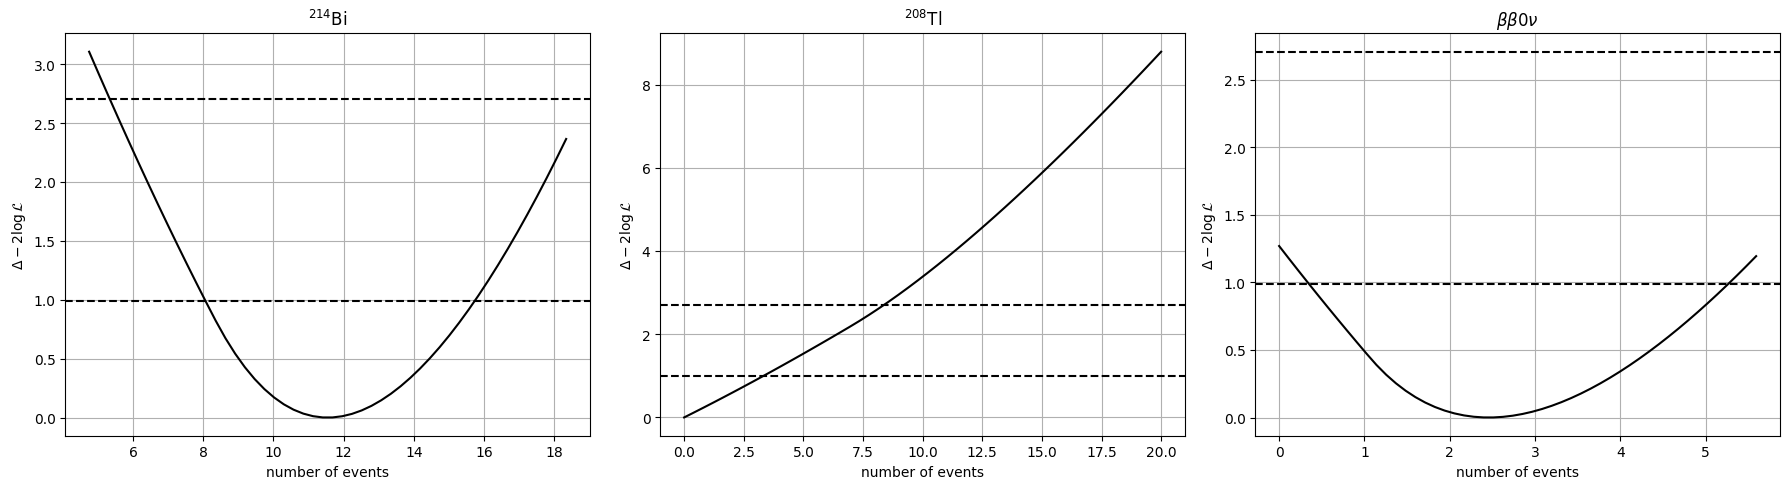

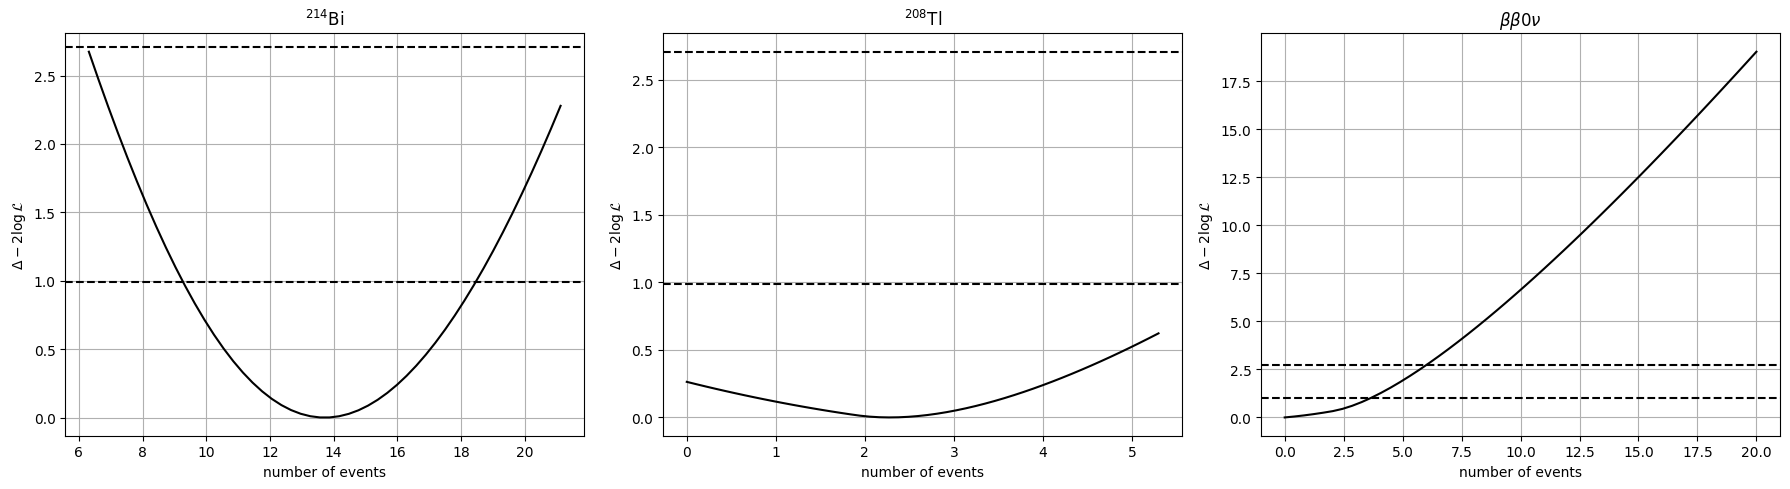

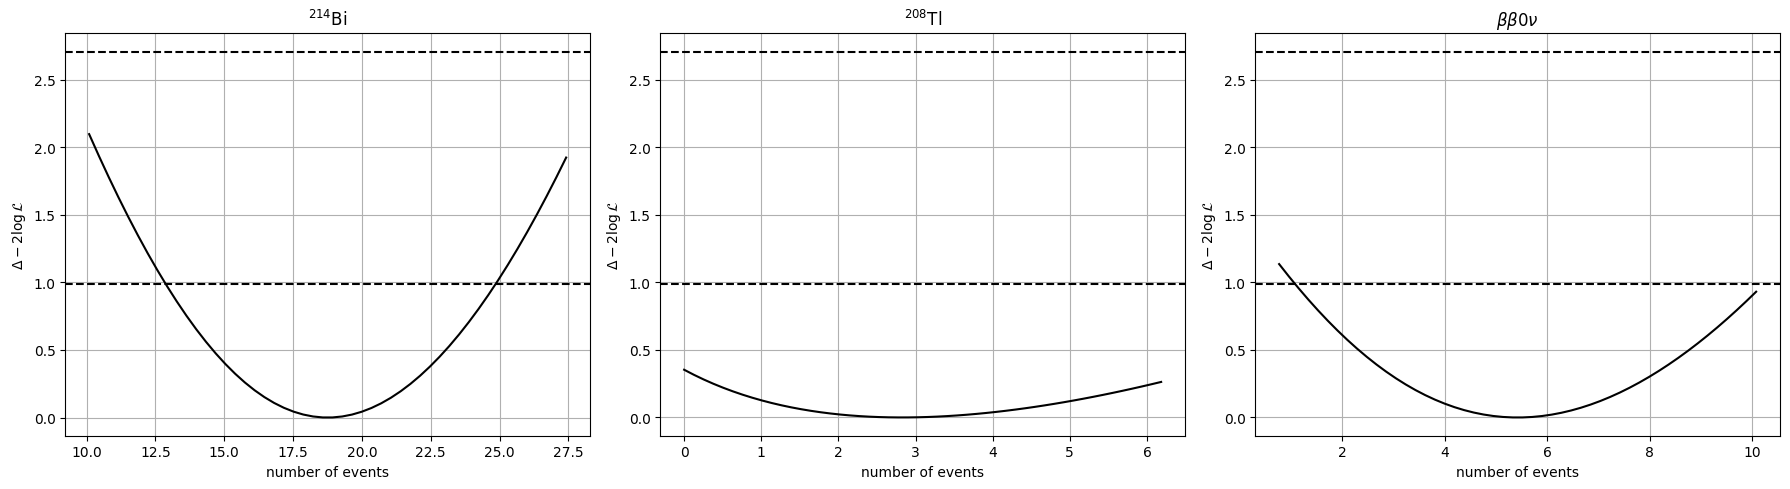

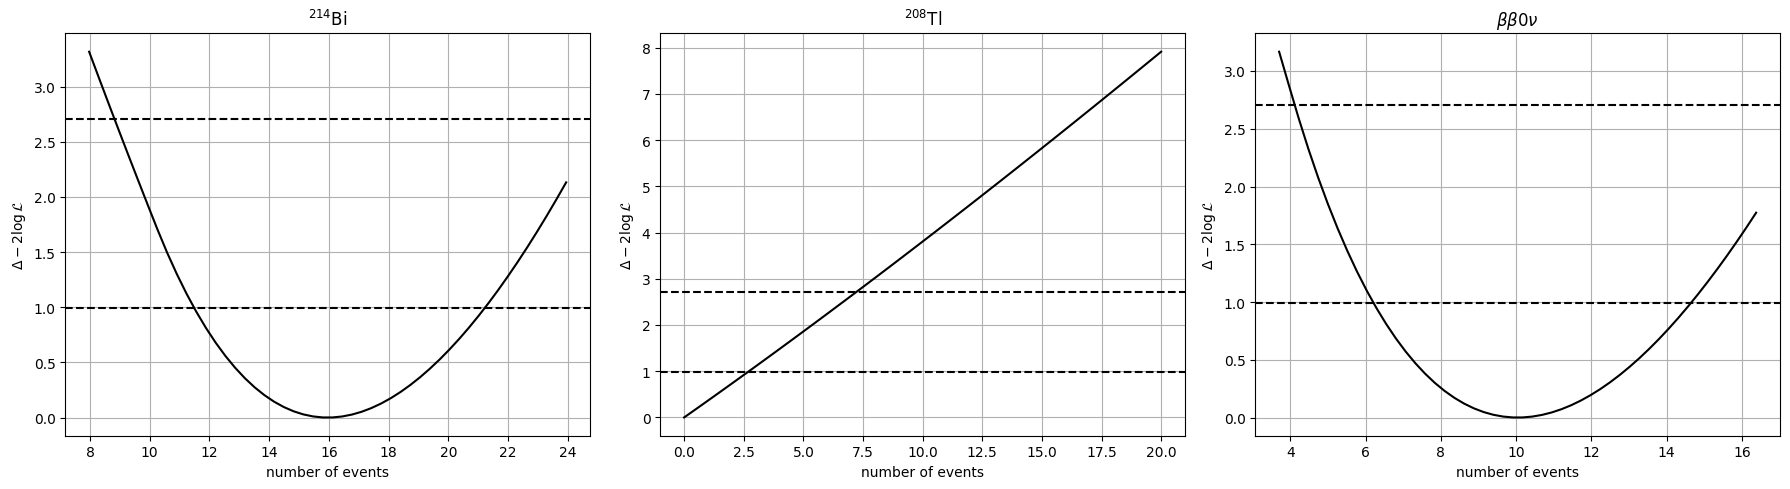

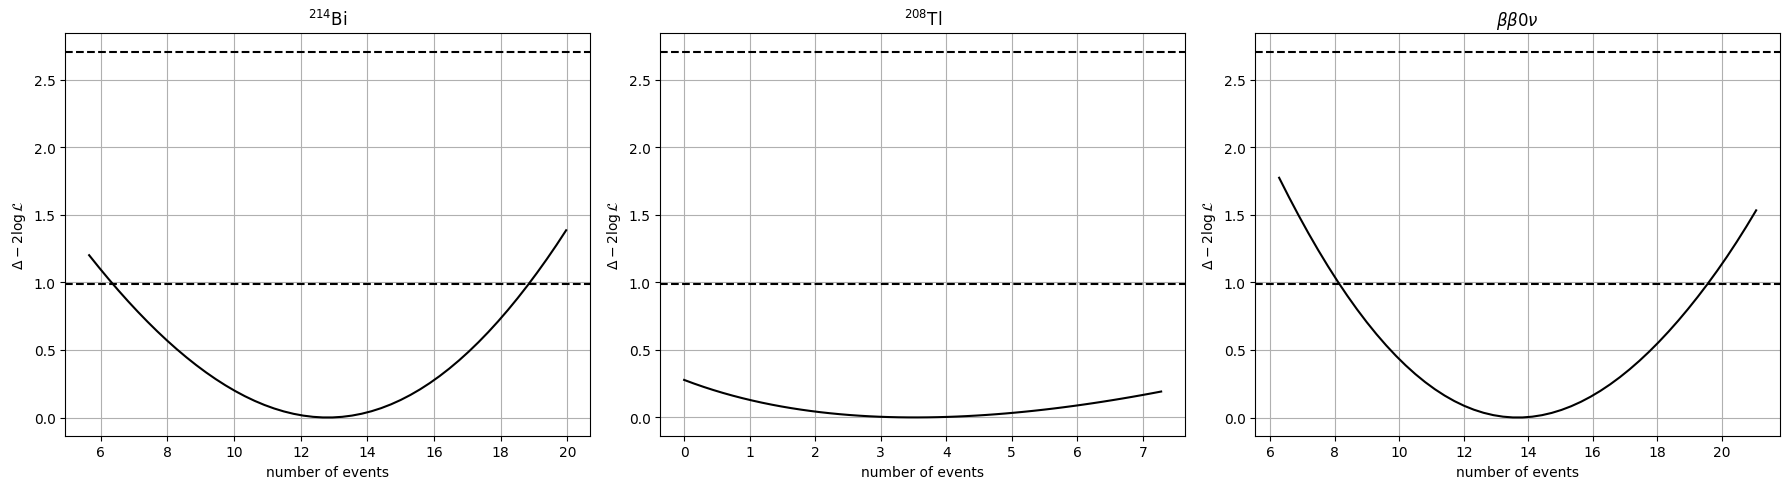

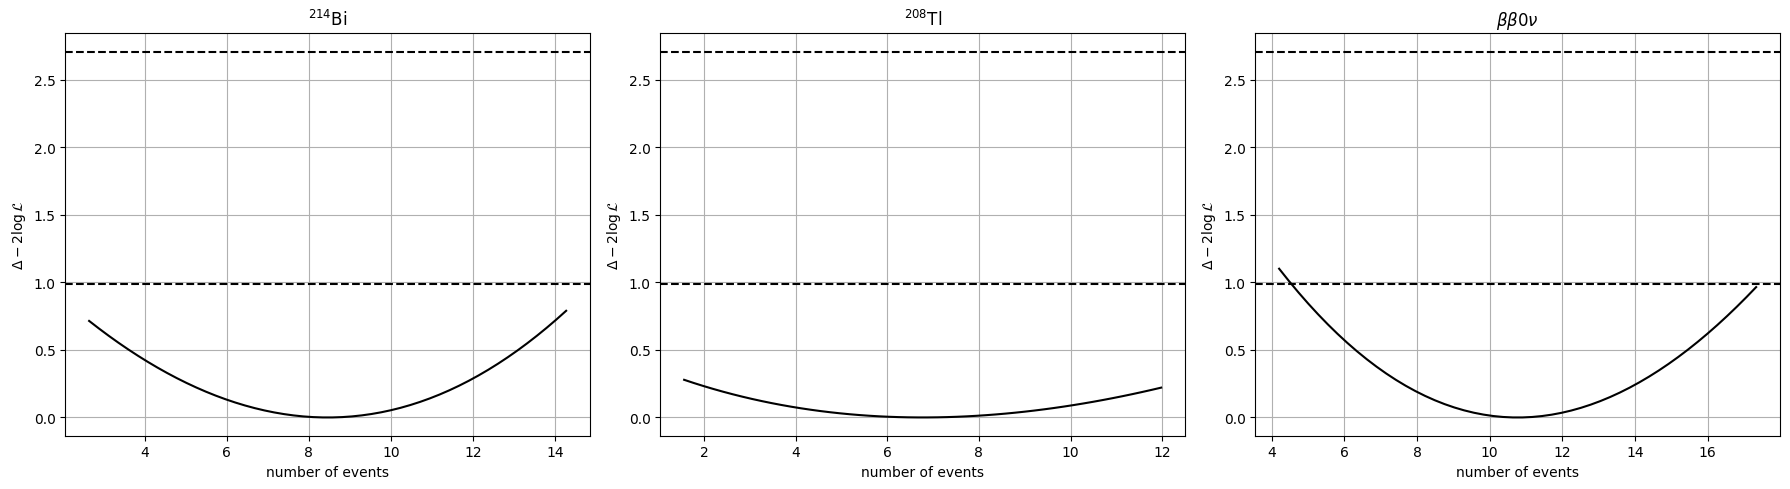

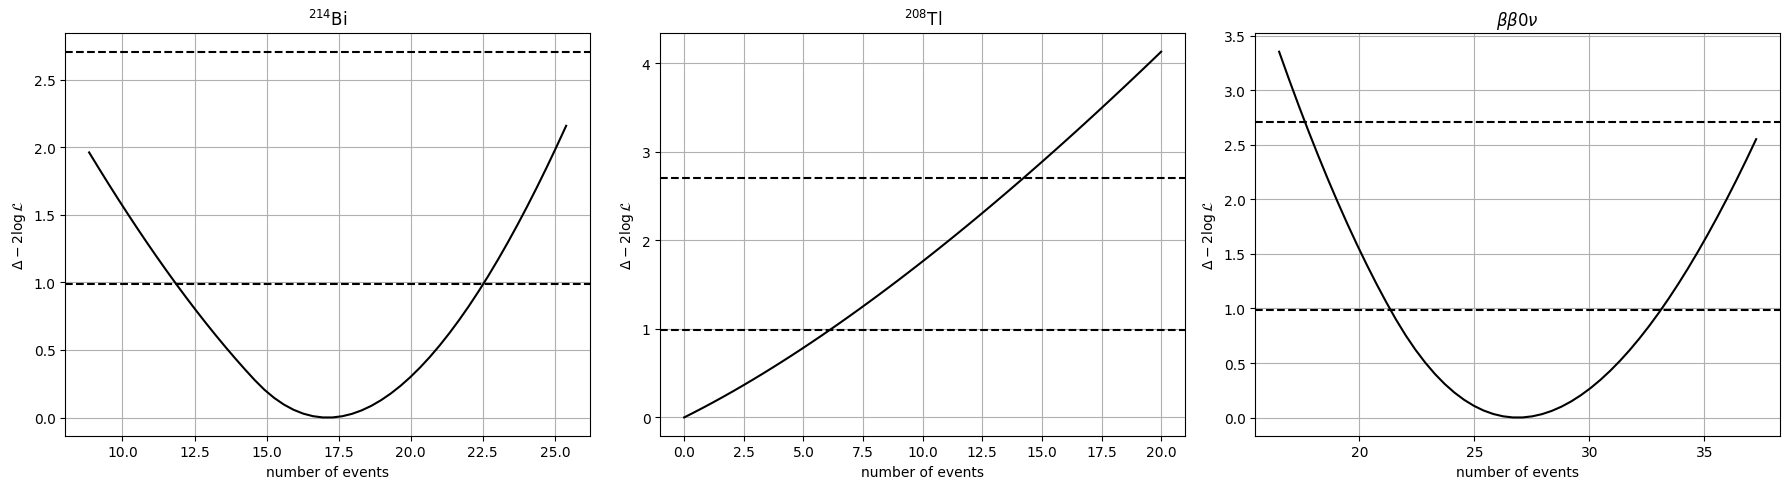

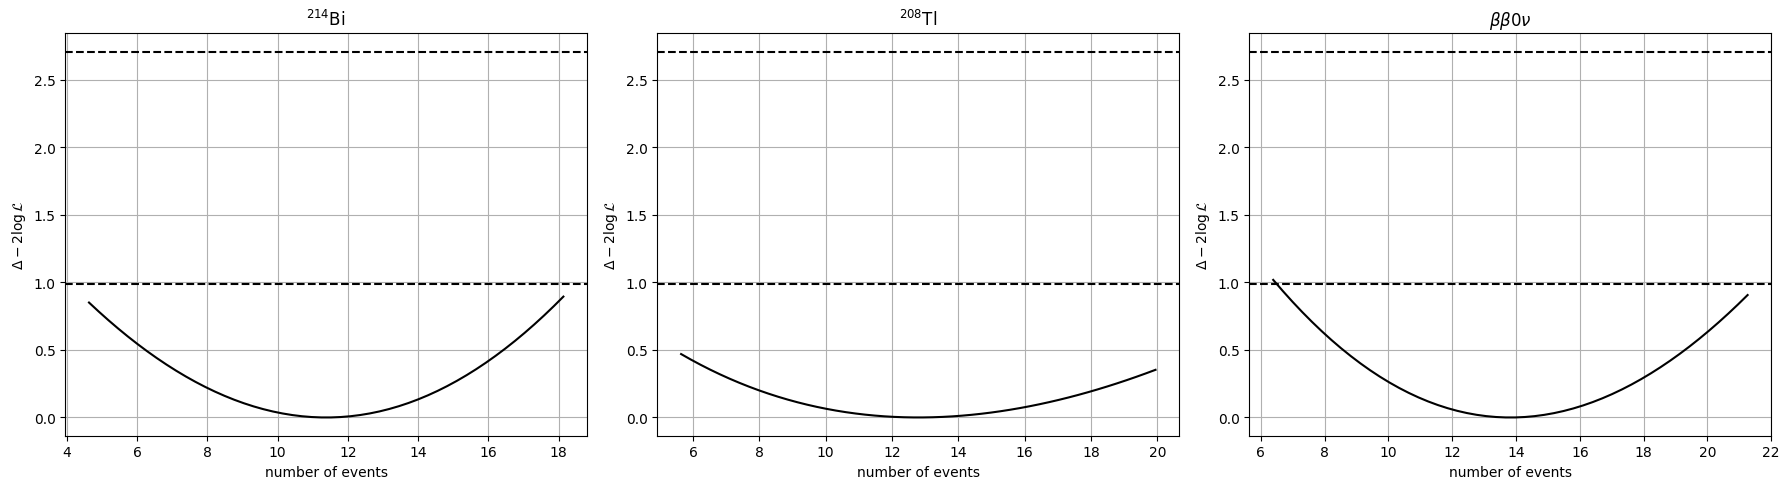

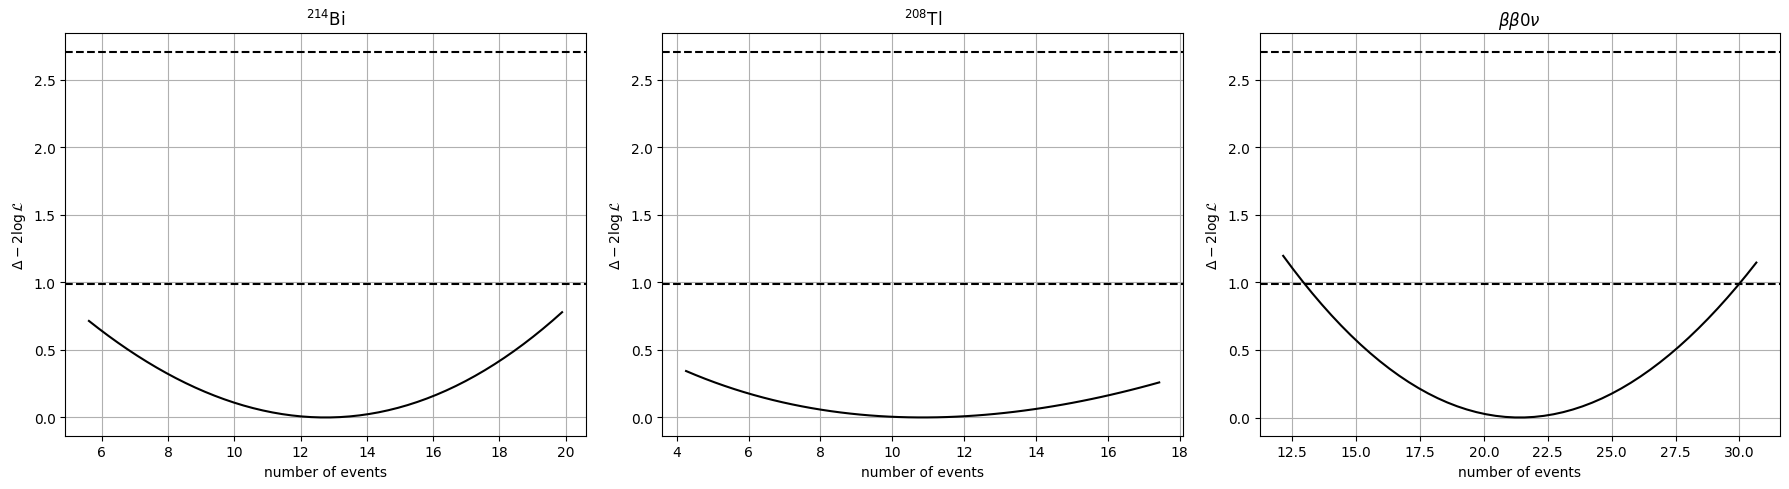

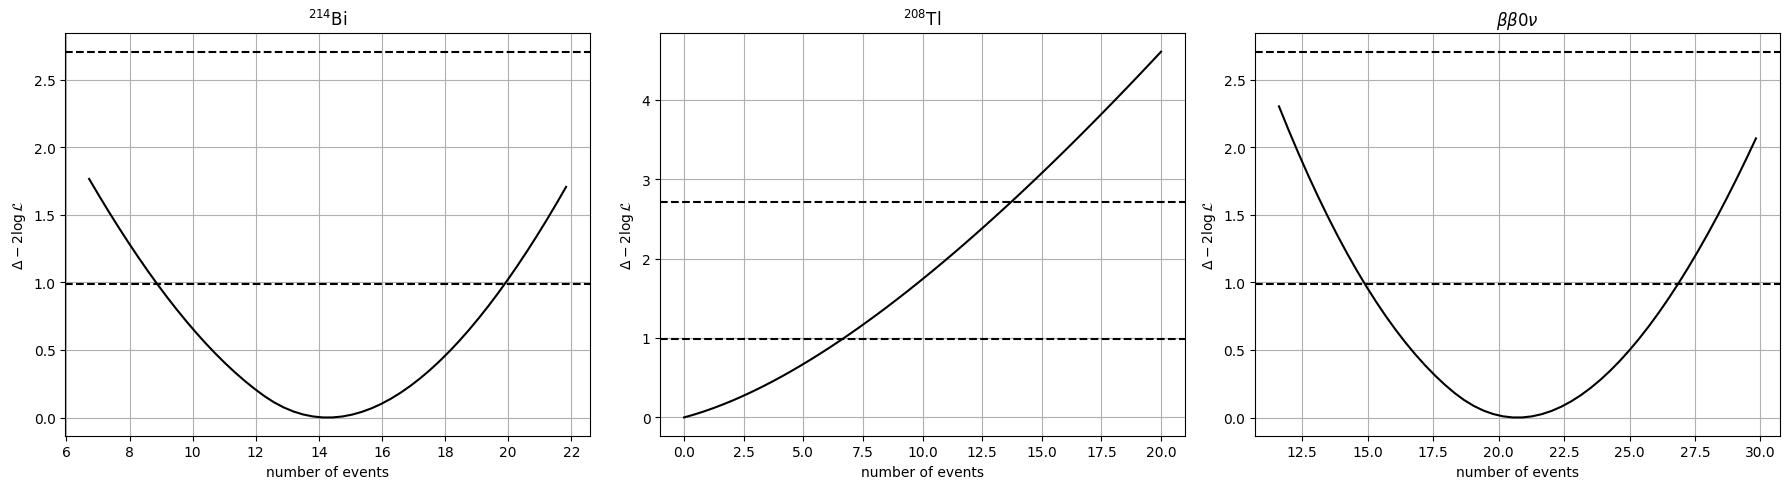

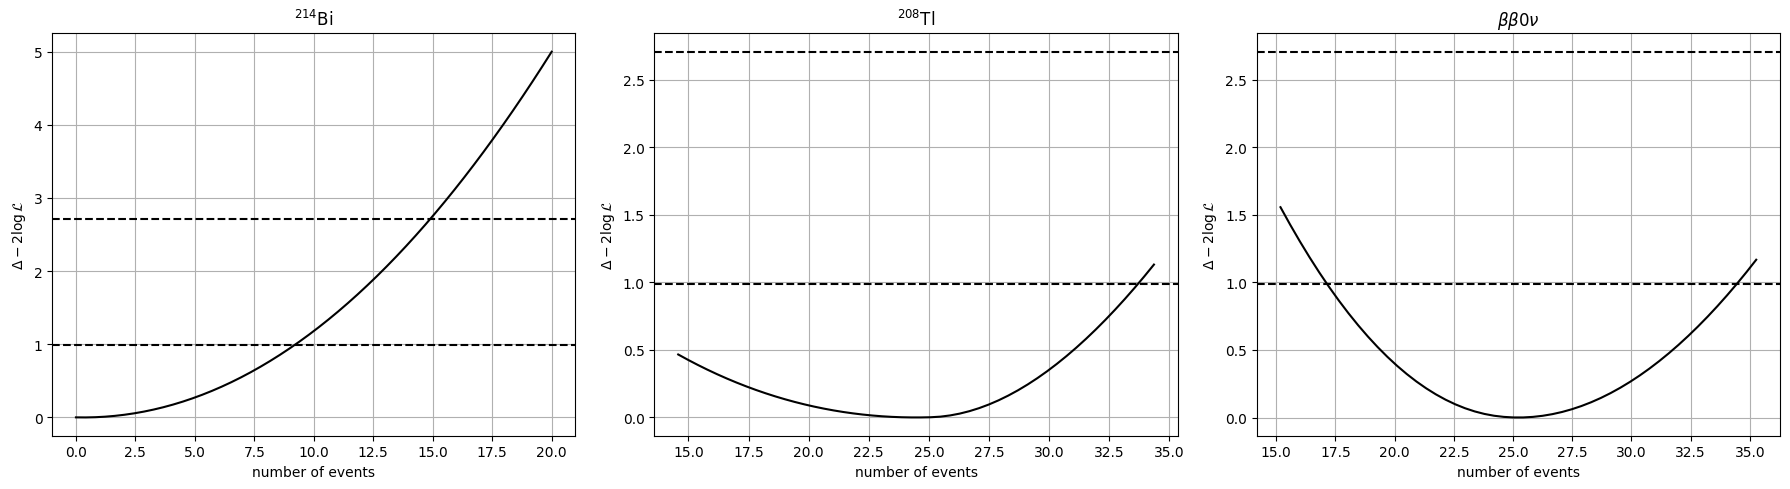

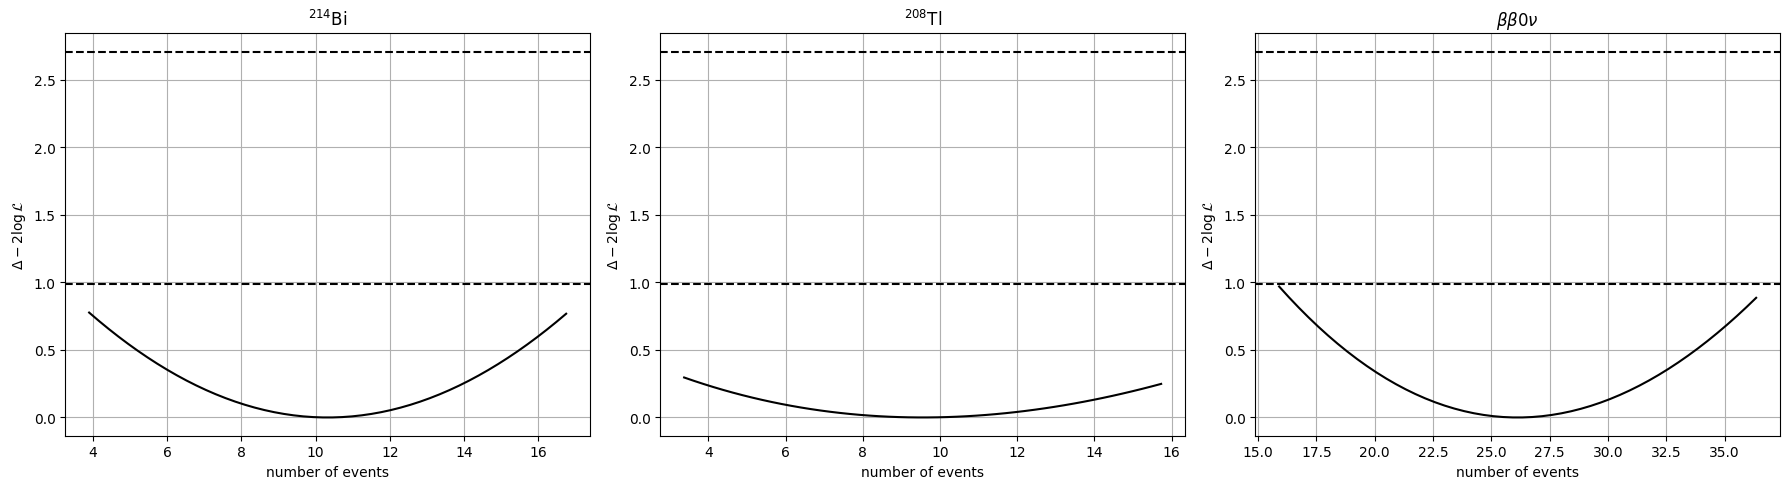

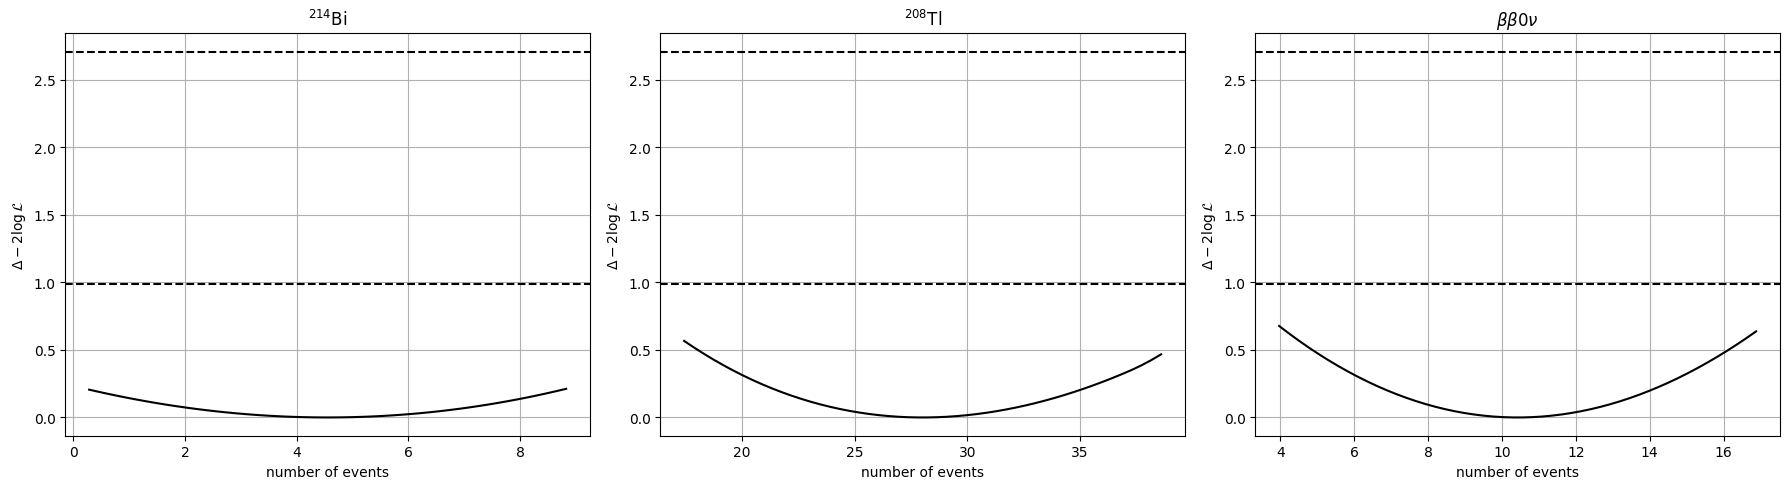

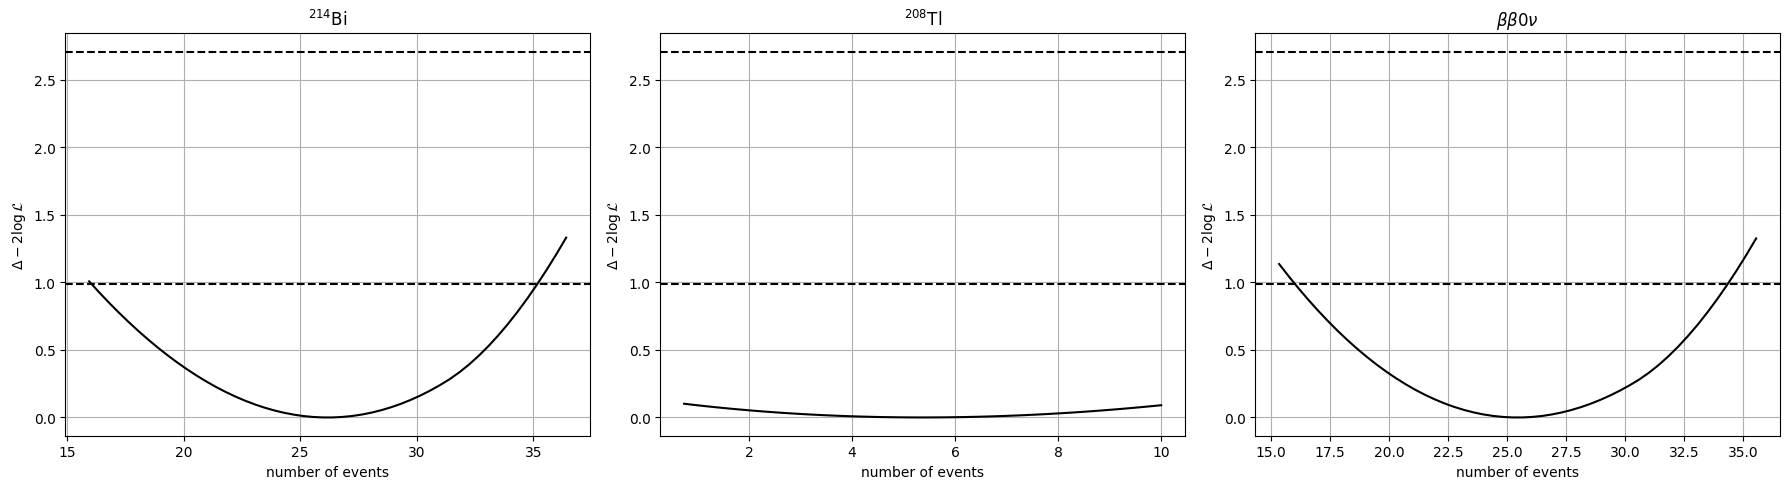

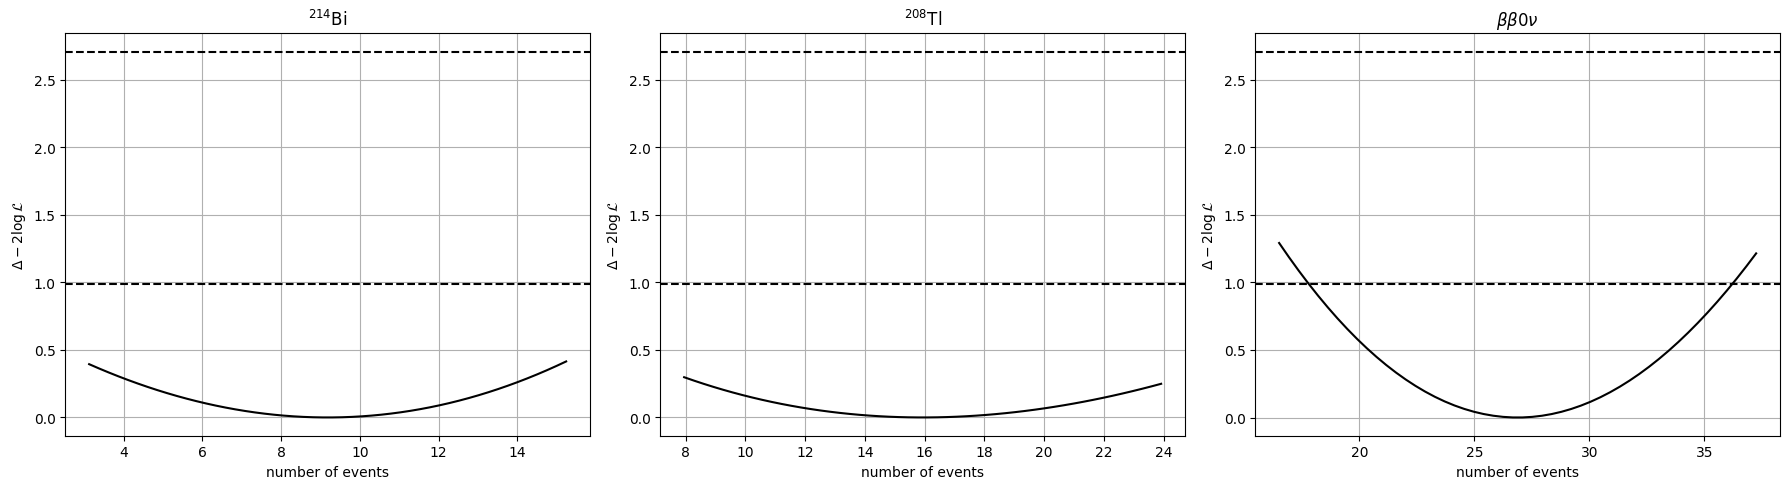

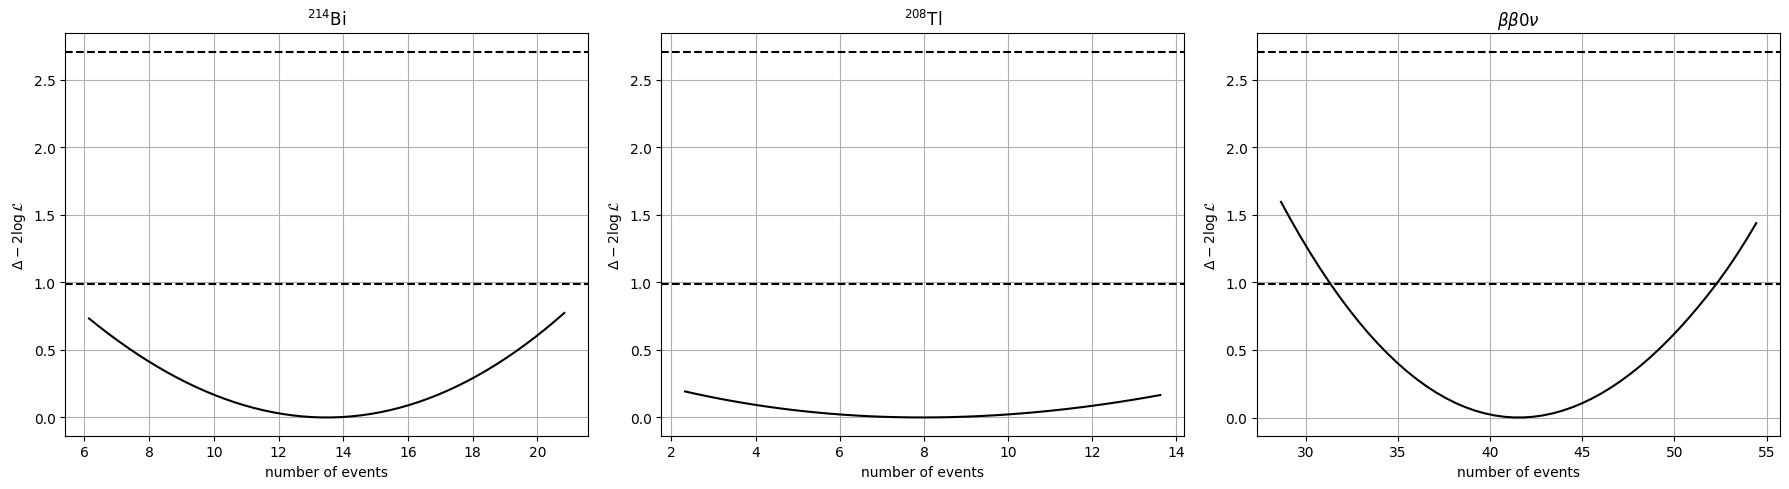

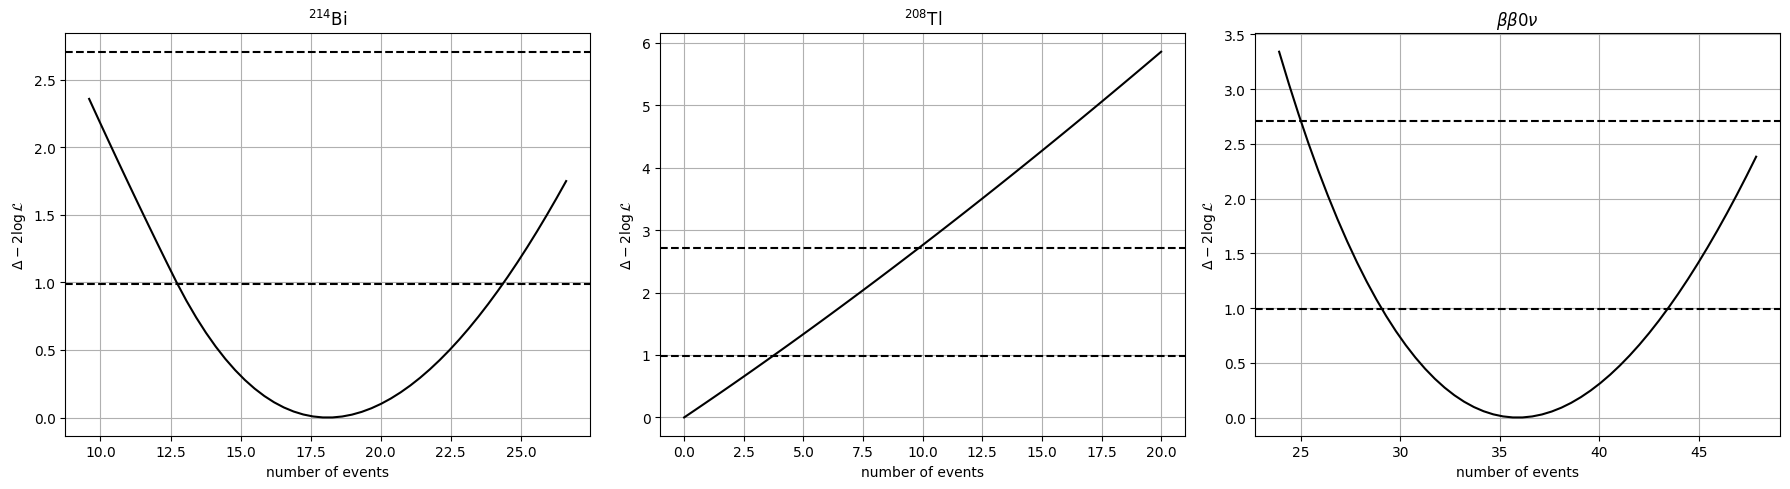

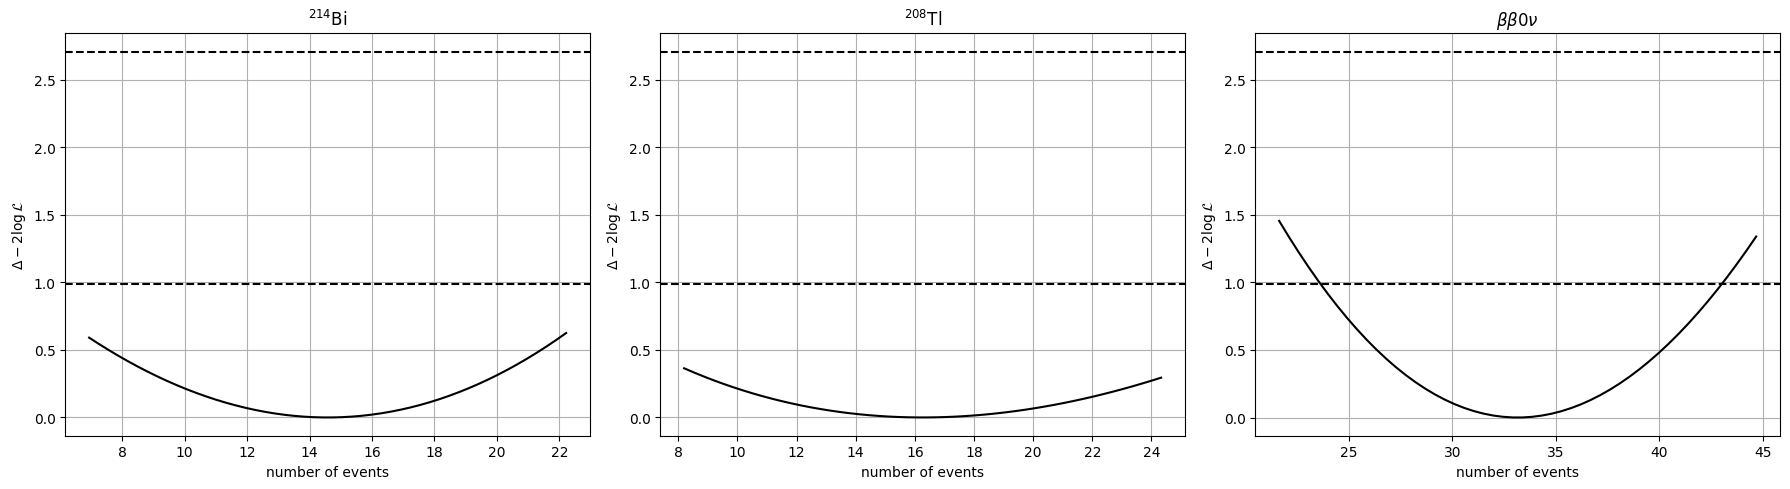

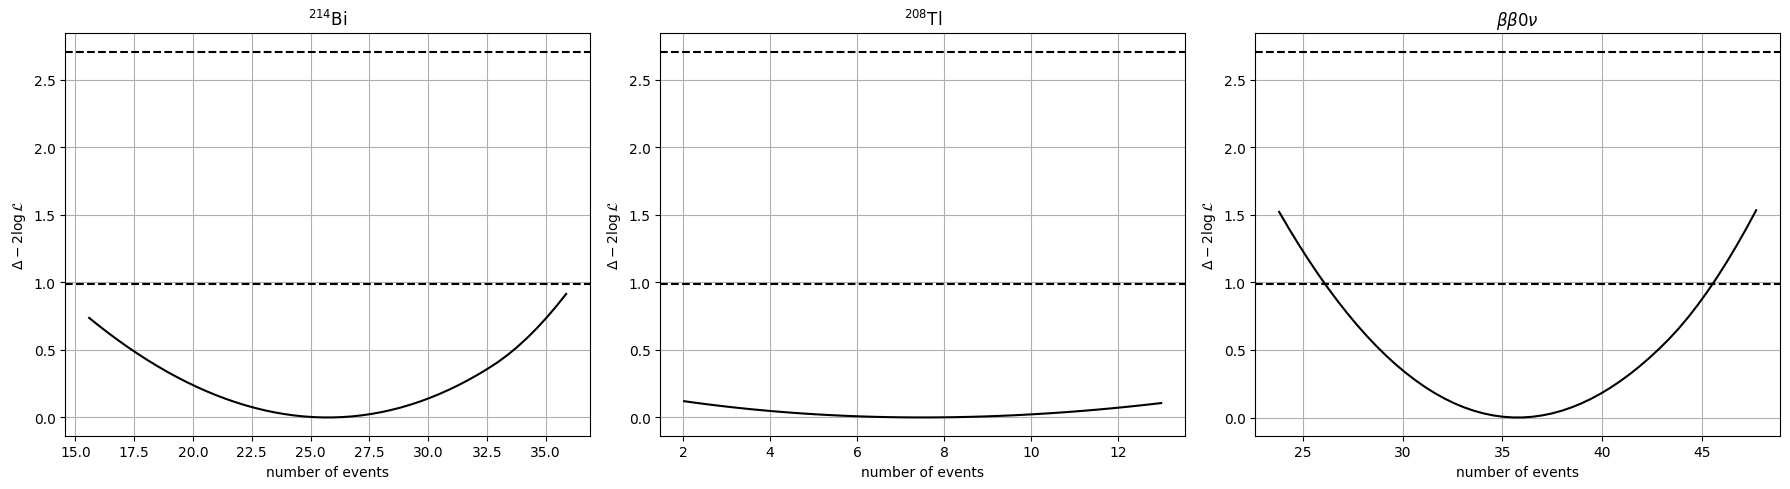

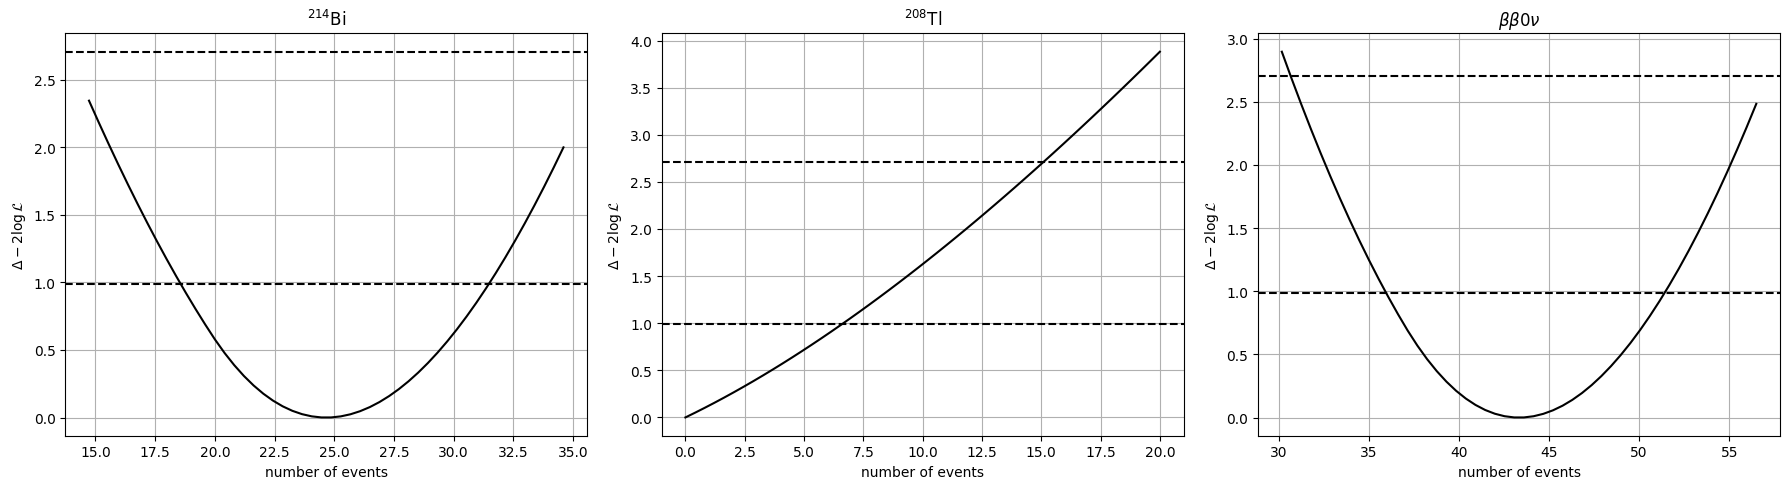

In [205]:
for j,factor in enumerate(factors):
    nis, tmus = fn.tmu_scan(values[j], n_est[j], ell[j], sizes = (2., 2., 2.))
    pltfn.plot_tmu_scan(nis, tmus, titles = sample_names_latex)

In [206]:
for j,factor in enumerate(factors):
    print("=="*30)
    print(f"FACTOR = {factor} \n")
    
    cl    = 0.68

    nis, tmus = fn.tmu_scan(values[j], n_est[j], ell[j], sizes = (2., 2., 2.))

    mucis = [efit.tmu_conf_int(ni, tmu, cl) for ni, tmu in zip(nis, tmus)]
    for i, ci in enumerate(mucis):
        print('Number of {:s} events CI at {:4.0f} % CL = ({:5.2f}, {:5.2f})'.format(sample_names[i], 100*cl, *ci))

FACTOR = 0.0 

Number of Bi events CI at   68 % CL = ( 8.08, 15.57)
Number of Tl events CI at   68 % CL = ( 0.00,  3.27)
Number of bb events CI at   68 % CL = ( 0.46,  5.25)
FACTOR = 5.2631578947368425 

Number of Bi events CI at   68 % CL = ( 9.34, 18.41)
Number of Tl events CI at   68 % CL = ( 0.00,  5.30)
Number of bb events CI at   68 % CL = ( 0.00,  3.27)
FACTOR = 10.526315789473685 

Number of Bi events CI at   68 % CL = (12.92, 24.59)
Number of Tl events CI at   68 % CL = ( 0.00,  6.18)
Number of bb events CI at   68 % CL = ( 1.15, 10.08)
FACTOR = 15.789473684210527 

Number of Bi events CI at   68 % CL = (11.56, 21.01)
Number of Tl events CI at   68 % CL = ( 0.00,  2.45)
Number of bb events CI at   68 % CL = ( 6.29, 14.57)
FACTOR = 21.05263157894737 

Number of Bi events CI at   68 % CL = ( 6.53, 18.79)
Number of Tl events CI at   68 % CL = ( 0.00,  7.28)
Number of bb events CI at   68 % CL = ( 8.39, 19.56)
FACTOR = 26.315789473684212 

Number of Bi events CI at   68 % CL = ( 2

In [207]:
for j,factor in enumerate(factors):
    print("=="*30)
    print(f"FACTOR = {factor} \n")
    
    cl    = 0.68

    nis, tmus = fn.tmu_scan(values[j], n_est[j], ell[j], sizes = (2., 2., 2.))
    mucis = [efit.tmu_conf_int(ni, tmu, cl) for ni, tmu in zip(nis, tmus)]
    
    for i, ci in enumerate(mucis):
        print('Number of {:s} events CI at {:4.0f} % CL = {:5.2f}  {:5.2f} +{:5.2f}'.format(sample_names[i], 100*cl, 
                                                                                        result[j].x[i],
                                                                                        *(ci - result[j].x[i])))

FACTOR = 0.0 

Number of Bi events CI at   68 % CL = 11.54  -3.47 + 4.02
Number of Tl events CI at   68 % CL =  0.00   0.00 + 3.27
Number of bb events CI at   68 % CL =  2.46  -2.00 + 2.79
FACTOR = 5.2631578947368425 

Number of Bi events CI at   68 % CL = 13.72  -4.38 + 4.69
Number of Tl events CI at   68 % CL =  2.28  -2.28 + 3.02
Number of bb events CI at   68 % CL =  0.00   0.00 + 3.27
FACTOR = 10.526315789473685 

Number of Bi events CI at   68 % CL = 18.75  -5.83 + 5.83
Number of Tl events CI at   68 % CL =  2.82  -2.82 + 3.36
Number of bb events CI at   68 % CL =  5.42  -4.28 + 4.66
FACTOR = 15.789473684210527 

Number of Bi events CI at   68 % CL = 15.96  -4.40 + 5.05
Number of Tl events CI at   68 % CL =  0.00   0.00 + 2.45
Number of bb events CI at   68 % CL = 10.04  -3.75 + 4.53
FACTOR = 21.05263157894737 

Number of Bi events CI at   68 % CL = 12.81  -6.28 + 5.99
Number of Tl events CI at   68 % CL =  3.52  -3.52 + 3.75
Number of bb events CI at   68 % CL = 13.67  -5.28 + 5

### Compute the p-value under the no-signal hypothesis

We compute the p-value of the null hypothesis (that there is no signal).

In [208]:
for j,factor in enumerate(factors):
    print("=="*30)
    print(f"FACTOR = {factor} \n")
    
    # test the 0 value in the 2-position of the parameters (that is the number of bb events)
    q0 = efit.tmu(values[j], ell[j], result[j].x, 0, ipos = 2)
    z0 = np.sqrt(q0)
    p0 = 1 - stats.norm.cdf(z0)
    #p0 = stats.chi2.sf(q0, 1)/2.
    print('null hypothesis p-value {:1.2e}, {:4.2f} sigmas'.format(p0, z0))

FACTOR = 0.0 

null hypothesis p-value 1.30e-01, 1.13 sigmas
FACTOR = 5.2631578947368425 

null hypothesis p-value 5.00e-01, -0.00 sigmas
FACTOR = 10.526315789473685 

null hypothesis p-value 1.07e-01, 1.24 sigmas
FACTOR = 15.789473684210527 

null hypothesis p-value 2.89e-03, 2.76 sigmas
FACTOR = 21.05263157894737 

null hypothesis p-value 7.49e-03, 2.43 sigmas
FACTOR = 26.315789473684212 

null hypothesis p-value 4.01e-02, 1.75 sigmas
FACTOR = 31.578947368421055 

null hypothesis p-value 9.13e-06, 4.29 sigmas
FACTOR = 36.8421052631579 

null hypothesis p-value 2.87e-02, 1.90 sigmas
FACTOR = 42.10526315789474 

null hypothesis p-value 5.71e-03, 2.53 sigmas
FACTOR = 47.36842105263158 

null hypothesis p-value 3.24e-04, 3.41 sigmas
FACTOR = 52.631578947368425 

null hypothesis p-value 5.08e-04, 3.29 sigmas
FACTOR = 57.89473684210527 

null hypothesis p-value 4.63e-03, 2.60 sigmas
FACTOR = 63.15789473684211 

null hypothesis p-value 8.94e-02, 1.34 sigmas
FACTOR = 68.42105263157896 

null

### Estimate the half-life of the simulated experiment

We estimate the value of the half-life, $\mathcal{T}_{1/2}^{\beta\beta0\nu}$, using as inputs:

 * the estimated number of signal events in the enlarged energy window (from the fit)   
 * the total efficiency for selecting signal events
 * the exposure (kg·y)



The formula relating the half-life to the number of signal events is:

$$
\mathcal{T}_{1/2}^{\beta\beta0\nu} = \frac{\delta \, \epsilon^{\beta\beta}_E \, M \, t }{n^{\beta\beta}_E} \frac{N_A \, \log(2)}{W}
$$

Where:

  * $\delta$ is the abundance of $^{136}\mathrm{Xe}$ (in our detector, 0.9)
  * $\epsilon^{\beta\beta}_E$ is the efficiency of selecting signal events in the energy window (as a fraction, computed using MC)
  * $M$ is the mass of the detector (kg)
  * $t$ is the exposure time (y)
  * $N_A$ is the Avogadro number
  * $W$ is the atomic mass (g/mol)

**Exercise**: Compute the half-life and its uncertainty!

In [209]:
def tau(nbb):
        delta    = 0.9         # 136Xe abundance
        W        = 0.136       # atomic mass in kg/mol
        NA       = constants.Avogadro
        eff_RoI  = collpars.eff_bb_RoI  # signal efficiency in RoI
        Mt       = collpars.exposure     # exposure in kg*y
        return delta * eff_RoI * Mt * NA * np.log(2) / (nbb * W)


factor = 0.00 | n_bb =    2.456  [   0.456,    5.248] | tau =  5.736e+26 y  (- 3.052e+26, + 2.514e+27)
factor = 5.26 | n_bb =    0.000  [   0.000,    3.265] | tau no definido
factor = 10.53 | n_bb =    5.423  [   1.146,   10.080] | tau =  2.598e+26 y  (- 1.200e+26, + 9.701e+26)
factor = 15.79 | n_bb =   10.041  [   6.290,   14.568] | tau =  1.403e+26 y  (- 4.360e+25, + 8.366e+25)
factor = 21.05 | n_bb =   13.670  [   8.388,   19.555] | tau =  1.031e+26 y  (- 3.102e+25, + 6.490e+25)
factor = 26.32 | n_bb =   10.770  [   4.742,   17.333] | tau =  1.308e+26 y  (- 4.953e+25, + 1.663e+26)
factor = 31.58 | n_bb =   26.882  [  21.592,   33.019] | tau =  5.241e+25 y  (- 9.740e+24, + 1.284e+25)
factor = 36.84 | n_bb =   13.823  [   6.691,   21.259] | tau =  1.019e+26 y  (- 3.565e+25, + 1.086e+26)
factor = 42.11 | n_bb =   21.406  [  13.285,   29.903] | tau =  6.581e+25 y  (- 1.870e+25, + 4.023e+25)
factor = 47.37 | n_bb =   20.723  [  14.963,   26.855] | tau =  6.798e+25 y  (- 1.552e+25, + 2.61

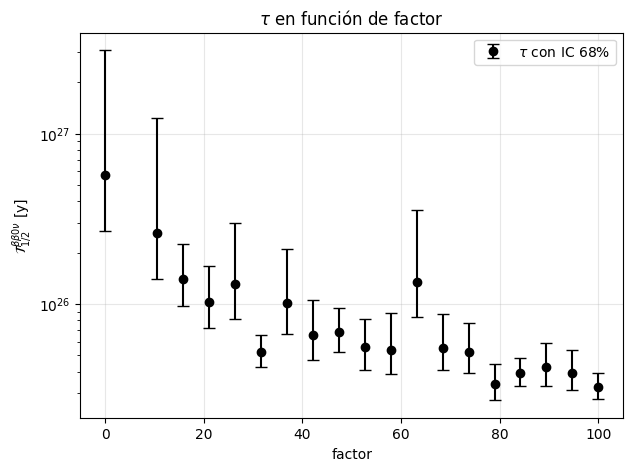

In [210]:
cl = 0.68

tau_array = []
tau_err_l = []
tau_err_h = []
n_bb_fit  = []
n_bb_low  = []
n_bb_high = []

for j, factor in enumerate(factors):

    # Mejor ajuste para bb
    nbb = float(n_est[j][2])

    # Intervalo de confianza de bb a 68%
    nis, tmus = fn.tmu_scan(values[j], n_est[j], ell[j], sizes=(2., 2., 2.))
    ci_bb = efit.tmu_conf_int(nis[2], tmus[2], cl)
    nlo, nhi = map(float, ci_bb)

    n_bb_fit.append(nbb)
    n_bb_low.append(nlo)
    n_bb_high.append(nhi)

    # Valor central
    tau_c = tau(nbb)

    # Como tau = K/n, el intervalo se invierte:
    # n in [nlo, nhi]  --> tau in [tau(nhi), tau(nlo)]
    tau_min = tau(nhi) if nhi > 0 else np.nan
    tau_max = tau(nlo) if nlo > 0 else np.inf

    err_l = tau_c - tau_min if np.isfinite(tau_min) else np.nan
    err_h = tau_max - tau_c if np.isfinite(tau_max) else np.nan

    tau_array.append(tau_c)
    tau_err_l.append(err_l)
    tau_err_h.append(err_h)

    if np.isfinite(tau_c) and np.isfinite(tau_max):
        print(
            f"factor = {factor:4.2f} | "
            f"n_bb = {nbb:8.3f}  [{nlo:8.3f}, {nhi:8.3f}] | "
            f"tau = {tau_c:10.3e} y  (-{err_l:10.3e}, +{err_h:10.3e})"
        )
    elif np.isfinite(tau_c):
        print(
            f"factor = {factor:4.2f} | "
            f"n_bb = {nbb:8.3f}  [{nlo:8.3f}, {nhi:8.3f}] | "
            f"tau = {tau_c:10.3e} y  (cota superior infinita)"
        )
    else:
        print(
            f"factor = {factor:4.2f} | "
            f"n_bb = {nbb:8.3f}  [{nlo:8.3f}, {nhi:8.3f}] | "
            f"tau no definido"
        )

tau_array = np.array(tau_array, dtype=float)
tau_err_l = np.array(tau_err_l, dtype=float)
tau_err_h = np.array(tau_err_h, dtype=float)
factors_a = np.array(factors, dtype=float)

# --- Plot tau vs factor ---
plt.figure(figsize=(7,5))

mask_err = np.isfinite(tau_array) & np.isfinite(tau_err_l) & np.isfinite(tau_err_h)
if np.any(mask_err):
    plt.errorbar(
        factors_a[mask_err],
        tau_array[mask_err],
        yerr=[tau_err_l[mask_err], tau_err_h[mask_err]],
        fmt='o',
        capsize=4,
        label=r'$\tau$ con IC 68%'
    )

mask_pts = np.isfinite(tau_array) & ~mask_err
if np.any(mask_pts):
    plt.plot(
        factors_a[mask_pts],
        tau_array[mask_pts],
        'o',
        label=r'$\tau$ sin barra superior finita'
    )

plt.xlabel('factor')
plt.ylabel(r'$\mathcal{T}_{1/2}^{\beta\beta0\nu}$ [y]')
plt.title(r'$\tau$ en función de factor')
plt.yscale('log')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()